# TCGA Reports - Detailed Exploratory Data Analysis
## Focus: TNM Stage Extraction and Analysis

This notebook performs a comprehensive EDA of TCGA pathology reports with emphasis on extracting and analyzing TNM (Tumor, Node, Metastasis) staging information.

## Section 1: Load TCGA_Reports.csv

**Objective**: Load the TCGA pathology reports dataset and verify successful data import

**What happens here**:
- Import required Python libraries for data processing, regex, and visualization
- Load the CSV file containing patient pathology reports
- Display dataset shape and preview first few rows
- Confirm data integrity after loading

In [21]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import os
import warnings
warnings.filterwarnings('ignore')

csv_file = 'TCGA_Reports.csv'
if not os.path.exists(csv_file):
    raise FileNotFoundError(f"Error: {csv_file} not found in current directory ({os.getcwd()})")

df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: (9523, 2)

First few rows:


,patient_filename,text
0,TCGA-BP-5195.25c0b433-5557-4165-922e-2c1eac9c26f0,Date of Recelpt: Clinical Diagnosis & History:...
1,TCGA-D7-8573.b7306a47-697d-4ed3-bbe1-81d49674a8f8,"Material: 1) Material: stomach, Method of coll..."
2,TCGA-EI-7004.13591eed-30e5-47a3-91be-7a370663d2d4,page 1 / 1. copy No. 3. Examination: Histopath...
3,TCGA-EB-A82B.23E186C6-739C-4EF1-8788-79AA89C6E87A,Patient ID: Gross Description: A mass is locat...
4,TCGA-A6-3808.e1505f65-72ef-438d-a5e1-93ed8bf6635d,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...


## Section 2: Inspect Data Structure

**Objective**: Understand dataset dimensions, data types, missing values, and text characteristics

**What happens here**:
- Display DataFrame shape (rows × columns)
- Show data type for each column (string, numeric, etc.)
- Identify missing/null values and calculate missing percentages
- Analyze report text field statistics (length distribution, unique patients)
- Assess data quality and completeness

In [22]:
# ============================================================================
# SECTION 2: EXPLORATORY DATA ANALYSIS - DATA STRUCTURE INSPECTION
# ============================================================================
# This section provides comprehensive overview of the dataset structure,
# data types, missing values, and text field characteristics

print("=" * 80)
print("DATA STRUCTURE OVERVIEW")
print("=" * 80)
print(f"\nDataFrame Shape: {df.shape}")  # Show total rows and columns
print(f"\nColumn Names and Data Types:")
print(df.dtypes)  # Display data type for each column

# ============================================================================
# MISSING VALUES ANALYSIS
# ============================================================================
# Identify data quality issues by analyzing null/missing values per column

print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_values = df.isnull().sum()  # Count null values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100  # Calculate percentage
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percentage.values
})
print(missing_df)  # Display missing values summary

# ============================================================================
# TEXT FIELD STATISTICS
# ============================================================================
# Analyze the text field (pathology reports) characteristics and distribution

print("\n" + "=" * 80)
print("TEXT FIELD STATISTICS")
print("=" * 80)

# Calculate various statistical measures for report length distribution
print(f"Average report length: {df['text'].str.len().mean():.0f} characters")  # Mean
print(f"Min report length: {df['text'].str.len().min():.0f} characters")  # Minimum
print(f"Max report length: {df['text'].str.len().max():.0f} characters")  # Maximum
print(f"Median report length: {df['text'].str.len().median():.0f} characters")  # Median

# ============================================================================
# DATA UNIQUENESS CHECK
# ============================================================================
# Check for data uniqueness and potential duplicates

print(f"\nUnique patients: {df['patient_filename'].nunique()}")  # Count unique patient IDs
print(f"Duplicate patients: {len(df) - df['patient_filename'].nunique()}")  # Identify duplicates

DATA STRUCTURE OVERVIEW

DataFrame Shape: (9523, 2)

Column Names and Data Types:
patient_filename    str
text                str
dtype: object

MISSING VALUES ANALYSIS
             Column  Missing_Count  Missing_Percentage
0  patient_filename              0                 0.0
1              text              0                 0.0

TEXT FIELD STATISTICS
Average report length: 3666 characters
Min report length: 2 characters
Max report length: 26162 characters
Median report length: 2854 characters

Unique patients: 9523
Duplicate patients: 0


## Section 3: Clean and Preprocess Columns

**Objective**: Prepare data for TNM extraction through standardization and normalization

**What happens here**:
- Create working copy of original data (preserves original)
- Standardize column names to lowercase
- Convert text fields to string type and handle null values
- Create uppercase version for case-insensitive pattern matching
- Display sample report text to understand format and content

In [23]:
# ============================================================================
# SECTION 3: DATA CLEANING AND PREPROCESSING
# ============================================================================
# Prepare data for TNM extraction by standardizing formats and creating
# uppercase version for case-insensitive regex pattern matching

print("Starting data preprocessing...\n")

# Create a working copy to preserve original data
# This ensures the original 'df' remains unchanged for reference
df_processed = df.copy()

# ============================================================================
# STANDARDIZE COLUMN NAMES
# ============================================================================
# Convert column names to lowercase and remove leading/trailing whitespace
# This ensures consistent column references throughout the analysis

df_processed.columns = df_processed.columns.str.lower().str.strip()

# ============================================================================
# NORMALIZE TEXT FIELD
# ============================================================================
# Ensure text field is string type and handle null/missing values
# Replace any NaN values with empty strings to prevent errors during regex operations

df_processed['text'] = df_processed['text'].astype(str).fillna('')

# ============================================================================
# CREATE UPPERCASE VERSION FOR PATTERN MATCHING
# ============================================================================
# Create uppercase version of text for case-insensitive pattern matching
# This allows regex to find TNM patterns regardless of capitalization
# (e.g., finds both "pT1" and "PT1" and "pt1")

df_processed['text_upper'] = df_processed['text'].str.upper()

# Confirm preprocessing completion and display updated structure
print("Data preprocessing completed!")
print(f"Processed DataFrame shape: {df_processed.shape}")  # Should match original
print(f"New columns created: {list(df_processed.columns)}")  # Show all columns

# ============================================================================
# SAMPLE INSPECTION
# ============================================================================
# Display sample of the report text to understand its structure and content

print("\n" + "=" * 80)
print("SAMPLE REPORT TEXT (first 500 characters of first report):")
print("=" * 80)
print(df_processed['text'].iloc[0][:500])  # Beginning of first report
print("\n... [MIDDLE CONTENT OMITTED FOR BREVITY] ...\n")
print(df_processed['text'].iloc[0][-500:])  # Ending of first report

Starting data preprocessing...

Data preprocessing completed!
Processed DataFrame shape: (9523, 3)
New columns created: ['patient_filename', 'text', 'text_upper']

SAMPLE REPORT TEXT (first 500 characters of first report):
Date of Recelpt: Clinical Diagnosis & History: Incidental 3 cm left upper pole renal mass. Specimens Submitted: 1: Kidney, Left Upper Pole; Partial Nephrectomy. DIAGNOSIS: 1. Kidney, Left Upper Pole; Partial Nephrectomy: Tumor Type: Renal cell carcinoma - Conventional (clear cell) type. Fuhrman Nuclear Grade: Nuclear grade II/IV. Tumor Size: Greatest diameter is 2.4 cm. Local Invasion (for renal cortical types): Not Identified. Renal Vein Invasion: Not identified. Surgical Margins: Free of tumor

... [MIDDLE CONTENT OMITTED FOR BREVITY] ...

n section control. T tumor. M margin. RS - representative sections. Summary of Sections: Part 1: Kidney, Left Upper Pole; Partial Nephrectomy. Block. Sect. Site. PCs. 1. fsc. 1. 2. m. 2. 1. rs. 1. 2. t. 2. Intraoperative Consulta

## Section 4: Extract TNM Stage Information

**Objective**: Use regex pattern matching to extract T, N, and M staging components from pathology reports

**What happens here**:
- Define `extract_tnm_components()` function with comprehensive documentation
- Implement regex patterns for pT, cT, pN, cN, pM, cM notation
- Handle multiple pattern formats (T1, T1a, T1b, etc.)
- Return dictionary with extracted stages and boolean flags
- Apply extraction function to all 9,523 reports
- Create new columns for T_stage, N_stage, M_stage, and composite flags
- Display sample extractions and extraction summary statistics

In [24]:

# ============================================================================
# SECTION 4: TNM STAGE EXTRACTION USING REGULAR EXPRESSIONS
# ============================================================================

def extract_tnm_components(text):
    """
    Extract T, N, and M components from pathology report text using regex.

    Key design decisions:
    - Negative lookbehind (?<![A-Z]) prevents matching T/N/M inside words
      e.g. EXTENT2, DEPTH3, INVASION1 are ignored
    - No whitespace allowed between the letter and its value
      prevents "PATIENT 1" → T=1
    - Subtypes [A-C] only valid after a digit, never standalone
    - Lookahead (?![A-BD-LO-WY-Z0-9]) for T and N:
        - Blocks all letters EXCEPT C (subtype, already consumed), N, M, X
        - Allows N/M to immediately follow a T or N value (handles T2N1M0)
        - Allows X to follow (for edge cases like T1X notation)
    - Combined pattern uses [\s,]* (zero or more) to handle both
      spaced (T2 N1 M0) and concatenated (T2N1M0) formats
    - Supports prefixes p, c, y, r (pathological, clinical, post-treatment, recurrence)
    """

    result = {
        'T_stage': None,
        'N_stage': None,
        'M_stage': None,
        'TNM_raw': None,
        'has_T': False,
        'has_N': False,
        'has_M': False,
    }

    text_upper = str(text).upper()

    # ===== COMBINED TNM STRING (try first — most reliable) =====
    # Handles: "T2 N1 M0", "pT2N1M0", "T2,N1,M0", "pT2 pN1 pM0"
    # [\s,]* allows zero or more spaces/commas between components
    tnm_pattern = re.search(
        r'(?<![A-Z])'
        r'([PCYR]?T(?:IS|X|[0-4][A-C]?))'
        r'[\s,]*'
        r'([PCYR]?N(?:X|[0-3][A-C]?))'
        r'[\s,]*'
        r'([PCYR]?M[01X])'
        r'(?![A-Z0-9])',
        text_upper
    )
    if tnm_pattern:
        result['TNM_raw'] = tnm_pattern.group(0).strip()
        # Extract individual values from the combined match for consistency
        t_val = re.search(r'T(IS|X|[0-4][A-C]?)', tnm_pattern.group(1))
        n_val = re.search(r'N(X|[0-3][A-C]?)', tnm_pattern.group(2))
        m_val = re.search(r'M([01X])', tnm_pattern.group(3))
        if t_val:
            result['T_stage'] = t_val.group(1)
            result['has_T'] = True
        if n_val:
            result['N_stage'] = n_val.group(1)
            result['has_N'] = True
        if m_val:
            result['M_stage'] = m_val.group(1)
            result['has_M'] = True
        return result

    # ===== INDIVIDUAL COMPONENT FALLBACK =====
    # Used when T, N, M appear separately throughout the report.
    # Lookahead (?![A-BD-LO-WY-Z0-9]) blocks all letters EXCEPT C, M, N, X
    # so that T2N1 (concatenated) is correctly parsed even without M present.

    # T STAGE: IS (in situ), X (unknown), 0–4 with optional subtype A/B/C
    t_match = re.search(
        r'(?<![A-Z])([PCYR]?T)(IS|X|[0-4][A-C]?)(?![A-BD-LO-WY-Z0-9])',
        text_upper
    )
    if t_match:
        result['T_stage'] = t_match.group(2)
        result['has_T'] = True

    # N STAGE: X (unknown), 0–3 with optional subtype A/B/C
    n_match = re.search(
        r'(?<![A-Z])([PCYR]?N)(X|[0-3][A-C]?)(?![A-BD-LO-WY-Z0-9])',
        text_upper
    )
    if n_match:
        result['N_stage'] = n_match.group(2)
        result['has_N'] = True

    # M STAGE: 0 (no metastasis), 1 (metastasis), X (unknown)
    m_match = re.search(
        r'(?<![A-Z])([PCYR]?M)([01X])(?![A-Z0-9])',
        text_upper
    )
    if m_match:
        result['M_stage'] = m_match.group(2)
        result['has_M'] = True

    return result

print("TNM Extraction Function Defined Successfully!")
print("Fixes applied:")
print("  1. Combined TNM pattern ([\s,]* separator) handles T2N1M0 AND T2 N1 M0")
print("  2. Individual T/N lookahead allows N/M to follow value (handles partial concat)")
print("  3. Combined match tried first; individual search used as fallback\n")

# ============================================================================
# APPLY TNM EXTRACTION TO ENTIRE DATASET
# ============================================================================
total_rows = len(df_processed)
print(f"Applying TNM extraction to all {total_rows} reports...")
print("This may take a few moments...\n")

tnm_results = df_processed['text_upper'].apply(extract_tnm_components)

df_processed['T_stage'] = tnm_results.apply(lambda x: x['T_stage'])
df_processed['N_stage'] = tnm_results.apply(lambda x: x['N_stage'])
df_processed['M_stage'] = tnm_results.apply(lambda x: x['M_stage'])
df_processed['TNM_raw'] = tnm_results.apply(lambda x: x['TNM_raw'])
df_processed['has_T'] = tnm_results.apply(lambda x: x['has_T'])
df_processed['has_N'] = tnm_results.apply(lambda x: x['has_N'])
df_processed['has_M'] = tnm_results.apply(lambda x: x['has_M'])
df_processed['has_complete_TNM'] = (
    df_processed['has_T'] & df_processed['has_N'] & df_processed['has_M']
)

print("✓ TNM extraction completed!")
print(f"  - T stages found : {df_processed['has_T'].sum():,} reports")
print(f"  - N stages found : {df_processed['has_N'].sum():,} reports")
print(f"  - M stages found : {df_processed['has_M'].sum():,} reports")
print(f"  - Complete TNM   : {df_processed['has_complete_TNM'].sum():,} reports\n")

print("Sample TNM Extractions (first 10 rows with complete TNM):")
sample_cols = ['patient_filename', 'T_stage', 'N_stage', 'M_stage', 'TNM_raw']
print(df_processed[df_processed['has_complete_TNM']][sample_cols].head(10))


TNM Extraction Function Defined Successfully!
Fixes applied:
  1. Combined TNM pattern ([\s,]* separator) handles T2N1M0 AND T2 N1 M0
  2. Individual T/N lookahead allows N/M to follow value (handles partial concat)
  3. Combined match tried first; individual search used as fallback

Applying TNM extraction to all 9523 reports...
This may take a few moments...

✓ TNM extraction completed!
  - T stages found : 5,023 reports
  - N stages found : 2,903 reports
  - M stages found : 2,640 reports
  - Complete TNM   : 1,567 reports

Sample TNM Extractions (first 10 rows with complete TNM):
                                     patient_filename T_stage N_stage M_stage  \
4   TCGA-A6-3808.e1505f65-72ef-438d-a5e1-93ed8bf6635d       3       0       X   
6   TCGA-24-1616.d8c764d9-0fe8-488e-8aa1-da73a8c10b01      3C       X       X   
15  TCGA-MH-A857.465C49A8-2050-434A-AC95-9144E46972DB       1       X       X   
16  TCGA-44-6777.600a1078-21f2-4267-9d3c-03f292fa6a32       2       X       X   
18  

## Section 5: Identify Rows with TNM Extraction

**Objective**: Categorize and display reports by extraction success level

**What happens here**:
- Filter and separate reports into three categories:
  1. **Complete TNM**: All three components (T, N, M) successfully extracted
  2. **Partial TNM**: At least one component extracted but not all three
  3. **No TNM**: No TNM components found in the report
- Display counts and percentages for each category
- Show sample data from each category for inspection
- Prepare complete TNM data for export

In [25]:
# ============================================================================
# SECTION 5: CATEGORIZE ROWS BY TNM EXTRACTION SUCCESS
# ============================================================================
# Separate reports into three categories based on TNM extraction success level.
# This segmentation helps identify data quality and staging information availability.

# ===== CATEGORY 1: COMPLETE TNM EXTRACTION =====
# Reports where all three components (T, N, and M) were successfully extracted
# These are the most valuable for comprehensive cancer staging analysis
rows_with_complete_tnm = df_processed[df_processed['has_complete_TNM']].copy()

# ===== CATEGORY 2: PARTIAL TNM EXTRACTION =====
# Reports where at least one TNM component was found, but not all three
# Uses OR logic (|) to find any component, AND NOT (~) complete to exclude the complete set
# These reports may still be useful but provide incomplete staging information
rows_with_partial_tnm = df_processed[
    ((df_processed['has_T'] | df_processed['has_N'] | df_processed['has_M']) & 
     ~df_processed['has_complete_TNM'])
].copy()

# ===== CATEGORY 3: NO TNM EXTRACTION =====
# Reports where none of the TNM components (T, N, or M) were found
# These may use alternative staging systems or lack staging information
rows_without_tnm = df_processed[
    ~(df_processed['has_T'] | df_processed['has_N'] | df_processed['has_M'])
].copy()

# ============================================================================
# DISPLAY COMPLETE TNM EXTRACTION RESULTS
# ============================================================================
print("=" * 80)
print("ROWS WITH COMPLETE TNM EXTRACTION (T, N, and M all present):")
print("=" * 80)
print(f"Total rows: {len(rows_with_complete_tnm)}")
print(f"Percentage: {(len(rows_with_complete_tnm)/len(df_processed)*100):.2f}%\n")

# Display detailed view of complete TNM extractions
display_cols = ['patient_filename', 'T_stage', 'N_stage', 'M_stage', 'TNM_raw']
print(rows_with_complete_tnm[display_cols].head(20))
print(f"\n... [{len(rows_with_complete_tnm) - 20} more rows] ...\n")

# ============================================================================
# DISPLAY PARTIAL TNM EXTRACTION RESULTS
# ============================================================================
print("=" * 80)
print("ROWS WITH PARTIAL TNM EXTRACTION (at least one component present):")
print("=" * 80)
print(f"Total rows: {len(rows_with_partial_tnm)}")
print(f"Percentage: {(len(rows_with_partial_tnm)/len(df_processed)*100):.2f}%\n")
print(rows_with_partial_tnm[display_cols].head(20))
print(f"\n... [{len(rows_with_partial_tnm) - 20} more rows] ...\n")

# ============================================================================
# DISPLAY NO TNM EXTRACTION RESULTS
# ============================================================================
print("=" * 80)
print("ROWS WITHOUT TNM EXTRACTION (no T, N, or M components):")
print("=" * 80)
print(f"Total rows: {len(rows_without_tnm)}")
print(f"Percentage: {(len(rows_without_tnm)/len(df_processed)*100):.2f}%\n")

# Mark complete TNM data as ready for export
rows_with_complete_tnm_export = rows_with_complete_tnm[display_cols].copy()
print(f"✓ List of {len(rows_with_complete_tnm)} rows with complete TNM extraction ready for export.")

ROWS WITH COMPLETE TNM EXTRACTION (T, N, and M all present):
Total rows: 1567
Percentage: 16.45%

                                      patient_filename T_stage N_stage  \
4    TCGA-A6-3808.e1505f65-72ef-438d-a5e1-93ed8bf6635d       3       0   
6    TCGA-24-1616.d8c764d9-0fe8-488e-8aa1-da73a8c10b01      3C       X   
15   TCGA-MH-A857.465C49A8-2050-434A-AC95-9144E46972DB       1       X   
16   TCGA-44-6777.600a1078-21f2-4267-9d3c-03f292fa6a32       2       X   
18   TCGA-56-7579.fd7a1de0-aa43-4d5a-b1e4-67473689bd58       3       1   
28   TCGA-HS-A5N8.23C57E99-5BF2-4CD2-AC62-E58D3FBBF273      2B       X   
35   TCGA-B6-A401.D76CF03A-54CD-4769-87AA-466473F41FC7      1C      1A   
38   TCGA-61-1907.ae7e4795-496e-47d0-ad60-cec04e5876b0      3C       X   
44   TCGA-CZ-5463.324d4d25-e72e-4faa-bd17-6c2201a2d6ce      3A       X   
51   TCGA-98-A539.9CC9A747-F186-4BAE-B63F-82DC061B06FA       3       1   
55   TCGA-78-8648.a439594e-b536-4bd3-a77a-fb50304de9a2       3       0   
58   TCGA-D6-A

## Section 6: Summarize TNM Extraction Coverage

**Objective**: Generate comprehensive statistics on extraction success rates and stage distributions

**What happens here**:
- Calculate and display overall extraction coverage (complete, partial, none)
- Show individual component coverage percentages for T, N, M separately
- Generate value distribution tables:
  - T stage values and their frequencies
  - N stage values and their frequencies
  - M stage values and their frequencies
- Provide insight into data quality and staging patterns
- Create statistical summary for reporting

In [26]:

# ============================================================================
# SECTION 6: SUMMARIZE TNM EXTRACTION COVERAGE
# ============================================================================

print("=" * 80)
print("TNM EXTRACTION COVERAGE SUMMARY")
print("=" * 80)

total_rows = len(df_processed)

# ===== EXTRACTION TYPE SUMMARY =====
summary_stats = {
    'Extraction Type': [
        'Complete TNM (T + N + M)',
        'Partial TNM (any component)',
        'No TNM Components',
        'Total'
    ],
    'Count': [
        len(rows_with_complete_tnm),
        len(rows_with_partial_tnm),
        len(rows_without_tnm),
        total_rows
    ],
    'Percentage': [
        f"{(len(rows_with_complete_tnm)/total_rows*100):.2f}%",
        f"{(len(rows_with_partial_tnm)/total_rows*100):.2f}%",
        f"{(len(rows_without_tnm)/total_rows*100):.2f}%",
        "100.00%"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))

# ===== INDIVIDUAL COMPONENT COVERAGE =====
print("\n" + "=" * 80)
print("INDIVIDUAL COMPONENT COVERAGE")
print("=" * 80)

component_stats = {
    'Component': ['T Stage', 'N Stage', 'M Stage'],
    'Present': [
        df_processed['has_T'].sum(),
        df_processed['has_N'].sum(),
        df_processed['has_M'].sum()
    ],
    'Missing': [
        (~df_processed['has_T']).sum(),
        (~df_processed['has_N']).sum(),
        (~df_processed['has_M']).sum()
    ]
}

component_df = pd.DataFrame(component_stats)
component_df['Coverage %'] = (component_df['Present'] / total_rows * 100).round(2)
print(component_df.to_string(index=False))

# ===== T STAGE DISTRIBUTION =====
print("\n" + "=" * 80)
print("T STAGE DISTRIBUTION (among extracted values)")
print("=" * 80)
t_dist = df_processed[df_processed['has_T']]['T_stage'].value_counts().sort_index()
print(t_dist)
print(f"Total reports with T stage: {t_dist.sum()}")

# ===== N STAGE DISTRIBUTION =====
print("\n" + "=" * 80)
print("N STAGE DISTRIBUTION (among extracted values)")
print("=" * 80)
n_dist = df_processed[df_processed['has_N']]['N_stage'].value_counts().sort_index()
print(n_dist)
print(f"Total reports with N stage: {n_dist.sum()}")

# ===== M STAGE DISTRIBUTION =====
print("\n" + "=" * 80)
print("M STAGE DISTRIBUTION (among extracted values)")
print("=" * 80)
m_dist = df_processed[df_processed['has_M']]['M_stage'].value_counts().sort_index()
print(m_dist)
print(f"Total reports with M stage: {m_dist.sum()}")


TNM EXTRACTION COVERAGE SUMMARY
            Extraction Type  Count Percentage
   Complete TNM (T + N + M)   1567     16.45%
Partial TNM (any component)   3852     40.45%
          No TNM Components   4104     43.10%
                      Total   9523    100.00%

INDIVIDUAL COMPONENT COVERAGE
Component  Present  Missing  Coverage %
  T Stage     5023     4500       52.75
  N Stage     2903     6620       30.48
  M Stage     2640     6883       27.72

T STAGE DISTRIBUTION (among extracted values)
T_stage
1      527
1A     226
1B     397
1C     139
2     1179
2A     185
2B     183
2C     143
3      949
3A     338
3B     239
3C     138
4      143
4A     146
4B      48
4C       1
IS      16
X       26
Name: count, dtype: int64
Total reports with T stage: 5023

N STAGE DISTRIBUTION (among extracted values)
N_stage
0     228
1     941
1A    152
1B     66
1C      5
2     323
2A     48
2B     86
2C     30
3      58
3A     42
3B      4
X     920
Name: count, dtype: int64
Total reports with N sta

## Section 7: Visualize Key Variables and TNM Distribution

**Objective**: Create 9 comprehensive visualizations showing TNM extraction patterns and data characteristics

**What happens here**:
- Configure matplotlib and seaborn styling for professional charts
- Create 3×3 subplot grid with the following visualizations:
  1. TNM Extraction Coverage (Pie Chart)
  2. Individual Component Coverage (Bar Chart)
  3. T Stage Distribution (Horizontal Bar)
  4. N Stage Distribution (Horizontal Bar)
  5. M Stage Distribution (Horizontal Bar)
  6. Report Length Distribution (Histogram)
  7. TNM Extraction Type Distribution (Bar Chart)
  8. TNM Component Combinations (Horizontal Bar)
  9. Missing Data Rate Heatmap
- Display comprehensive visual analysis of extraction results

Creating comprehensive visualization...



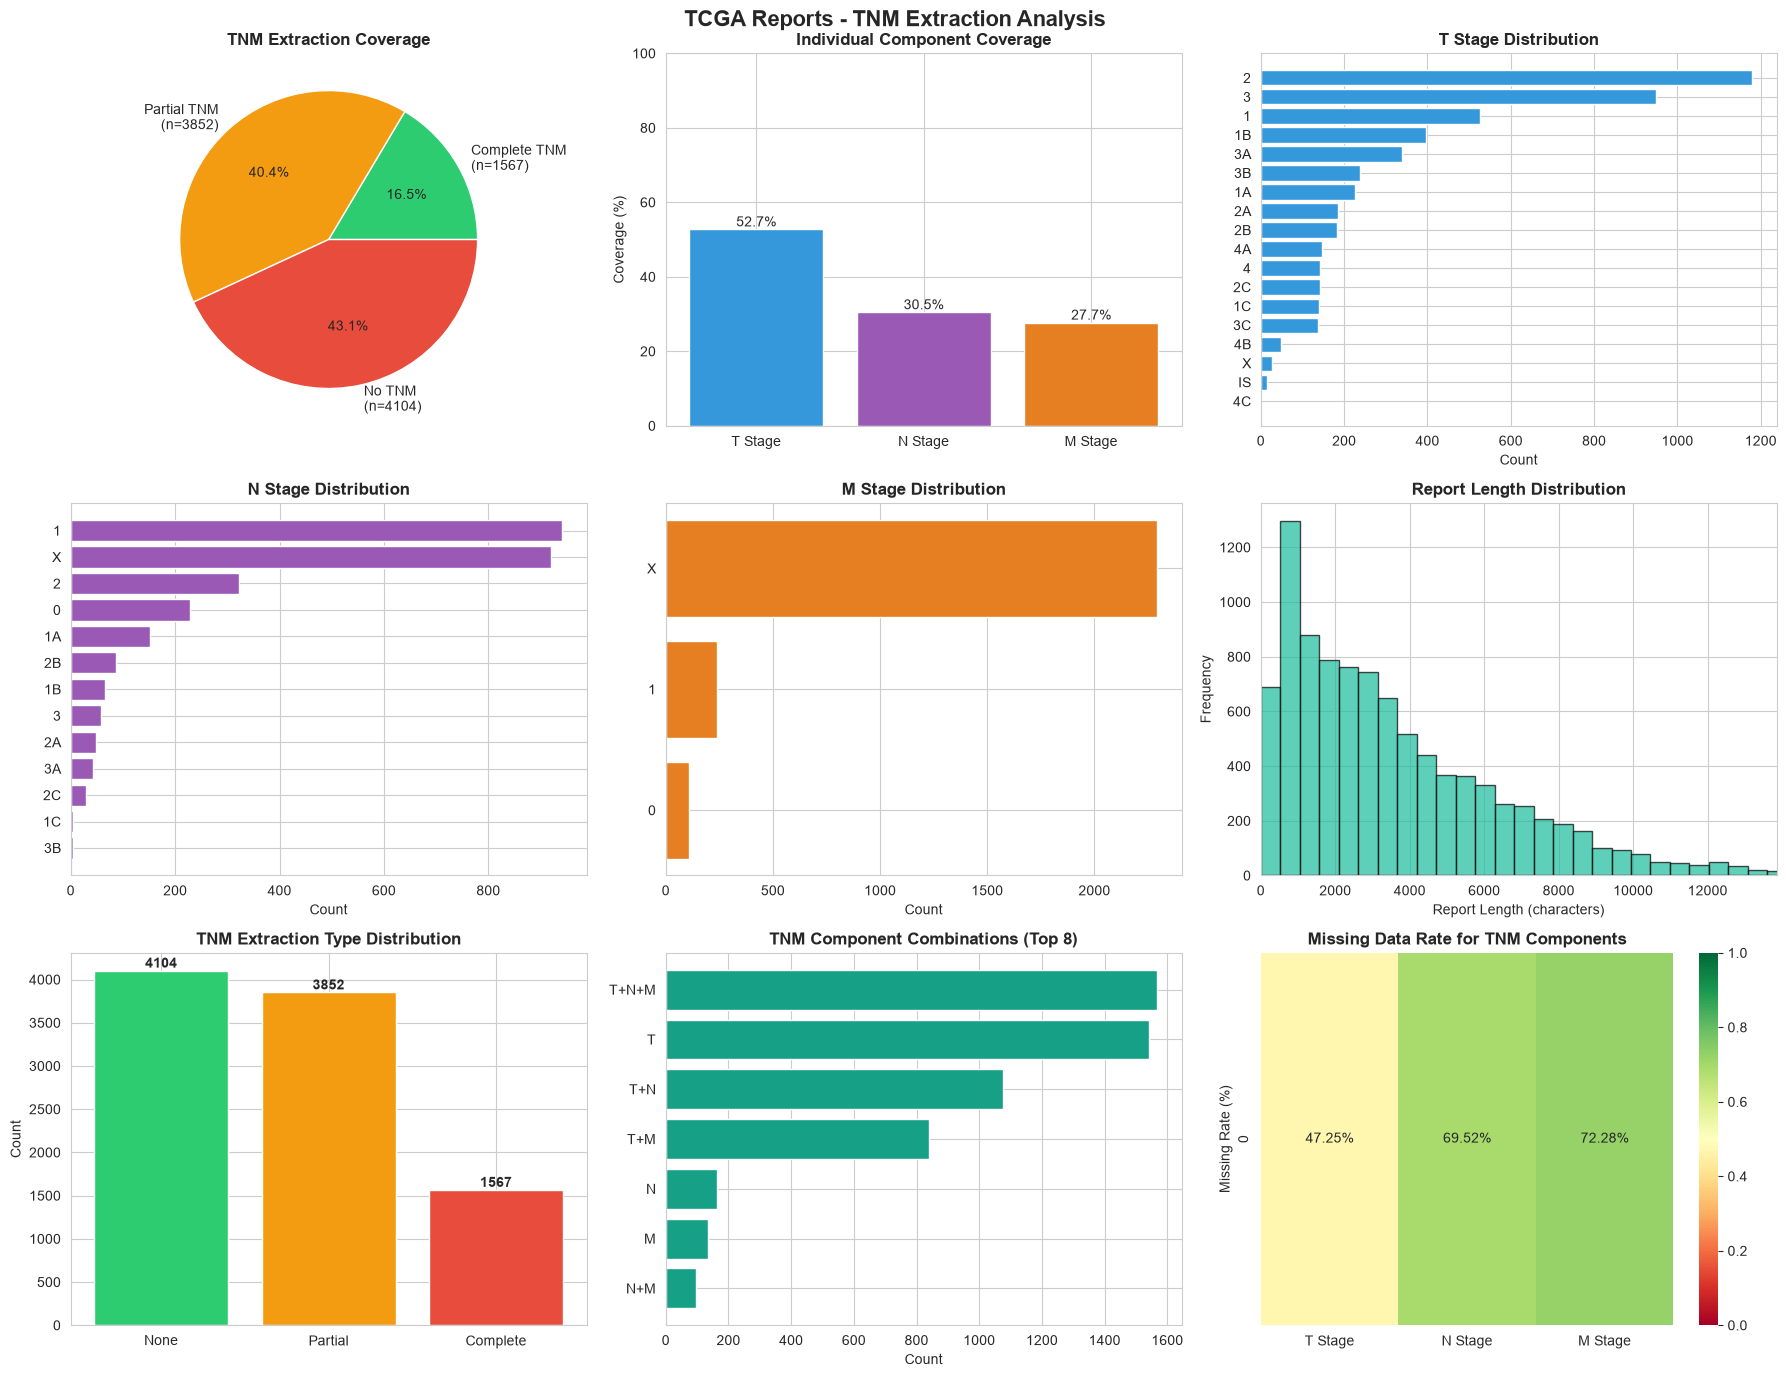

Visualization completed successfully!


In [27]:

# ============================================================================
# SECTION 7: VISUALIZE KEY VARIABLES AND TNM DISTRIBUTION
# ============================================================================

print("Creating comprehensive visualization...\n")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('TCGA Reports - TNM Extraction Analysis', fontsize=16, fontweight='bold')

# ===== CHART 1: TNM EXTRACTION COVERAGE (Pie Chart) =====
ax1 = axes[0, 0]
extraction_counts = [
    len(rows_with_complete_tnm),
    len(rows_with_partial_tnm),
    len(rows_without_tnm)
]
extraction_labels = [
    f'Complete TNM\n(n={len(rows_with_complete_tnm)})',
    f'Partial TNM\n(n={len(rows_with_partial_tnm)})',
    f'No TNM\n(n={len(rows_without_tnm)})'
]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax1.pie(extraction_counts, labels=extraction_labels, autopct='%1.1f%%', colors=colors)
ax1.set_title('TNM Extraction Coverage', fontweight='bold')

# ===== CHART 2: INDIVIDUAL COMPONENT COVERAGE (Bar Chart) =====
ax2 = axes[0, 1]
components = ['T Stage', 'N Stage', 'M Stage']
coverage = [
    (df_processed['has_T'].sum() / total_rows * 100),
    (df_processed['has_N'].sum() / total_rows * 100),
    (df_processed['has_M'].sum() / total_rows * 100)
]
bars = ax2.bar(components, coverage, color=['#3498db', '#9b59b6', '#e67e22'])
ax2.set_ylabel('Coverage (%)')
ax2.set_title('Individual Component Coverage', fontweight='bold')
ax2.set_ylim([0, 100])
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom')

# ===== CHART 3: T STAGE DISTRIBUTION (Horizontal Bar) =====
ax3 = axes[0, 2]
t_counts = df_processed[df_processed['has_T']]['T_stage'].value_counts()
ax3.barh(t_counts.index, t_counts.values, color='#3498db')
ax3.set_xlabel('Count')
ax3.set_title('T Stage Distribution', fontweight='bold')
ax3.invert_yaxis()

# ===== CHART 4: N STAGE DISTRIBUTION (Horizontal Bar) =====
ax4 = axes[1, 0]
n_counts = df_processed[df_processed['has_N']]['N_stage'].value_counts()
ax4.barh(n_counts.index, n_counts.values, color='#9b59b6')
ax4.set_xlabel('Count')
ax4.set_title('N Stage Distribution', fontweight='bold')
ax4.invert_yaxis()

# ===== CHART 5: M STAGE DISTRIBUTION (Horizontal Bar) =====
ax5 = axes[1, 1]
m_counts = df_processed[df_processed['has_M']]['M_stage'].value_counts()
ax5.barh(m_counts.index, m_counts.values, color='#e67e22')
ax5.set_xlabel('Count')
ax5.set_title('M Stage Distribution', fontweight='bold')
ax5.invert_yaxis()

# ===== CHART 6: REPORT LENGTH DISTRIBUTION (Histogram) =====
ax6 = axes[1, 2]
report_lengths = df_processed['text'].str.len()
ax6.hist(report_lengths, bins=50, color='#1abc9c', edgecolor='black', alpha=0.7)
ax6.set_xlabel('Report Length (characters)')
ax6.set_ylabel('Frequency')
ax6.set_title('Report Length Distribution', fontweight='bold')
ax6.set_xlim([0, report_lengths.quantile(0.99)])

# ===== CHART 7: TNM EXTRACTION TYPE DISTRIBUTION (Bar Chart) =====
ax7 = axes[2, 0]
extraction_type = []
for idx, row in df_processed.iterrows():
    if row['has_complete_TNM']:
        extraction_type.append('Complete')
    elif row['has_T'] or row['has_N'] or row['has_M']:
        extraction_type.append('Partial')
    else:
        extraction_type.append('None')

extraction_type_counts = pd.Series(extraction_type).value_counts()
ax7.bar(extraction_type_counts.index, extraction_type_counts.values,
        color=['#2ecc71', '#f39c12', '#e74c3c'])
ax7.set_ylabel('Count')
ax7.set_title('TNM Extraction Type Distribution', fontweight='bold')
for i, v in enumerate(extraction_type_counts.values):
    ax7.text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# ===== CHART 8: TNM COMPONENT COMBINATIONS (Horizontal Bar) =====
ax8 = axes[2, 1]
combinations = []
for idx, row in df_processed.iterrows():
    if row['has_T'] or row['has_N'] or row['has_M']:
        combo = []
        if row['has_T']: combo.append('T')
        if row['has_N']: combo.append('N')
        if row['has_M']: combo.append('M')
        combinations.append('+'.join(combo))

combo_counts = pd.Series(combinations).value_counts().head(8)
ax8.barh(combo_counts.index, combo_counts.values, color='#16a085')
ax8.set_xlabel('Count')
ax8.set_title('TNM Component Combinations (Top 8)', fontweight='bold')
ax8.invert_yaxis()

# ===== CHART 9: MISSING DATA HEATMAP =====
ax9 = axes[2, 2]
tnm_cols = ['has_T', 'has_N', 'has_M']
missing_data = df_processed[tnm_cols].astype(int)
missing_matrix = 1 - missing_data.mean()
sns.heatmap(missing_matrix.values.reshape(1, -1), annot=True, fmt='.2%',
            cbar=True, cmap='RdYlGn', ax=ax9, vmin=0, vmax=1,
            xticklabels=['T Stage', 'N Stage', 'M Stage'])
ax9.set_title('Missing Data Rate for TNM Components', fontweight='bold')
ax9.set_ylabel('Missing Rate (%)')

plt.tight_layout()
plt.show()

print("Visualization completed successfully!")


## Section 7.5: Word Cloud Visualizations

**Objective**: Generate word clouds to visualize the most frequently used terminology in pathology reports

**What happens here**:
- Create word clouds from report text using the WordCloud library
- Generate separate clouds for complete TNM, partial TNM, and all reports
- Visualize vocabulary distribution and common terms
- Display professional word clouds with custom styling
- Highlight dominant medical terminology patterns

In [28]:
# ============================================================================
# SECTION 7.2: CREATE WORDCLOUD OBJECTS FROM REPORT TEXT
# ============================================================================
# Generate word clouds from report text for visual analysis of terminology
# Configure WordCloud with professional styling and parameters

print("Creating word clouds from report text...\n")

# Common English stop words to exclude from visualization
stop_words = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 
                  'of', 'with', 'by', 'from', 'is', 'are', 'was', 'were', 'be', 'been',
                  'has', 'have', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
                  'should', 'may', 'might', 'must', 'can', 'this', 'that', 'these',
                  'those', 'it', 'its', 'as', 'if', 'so', 'than', 'not', 'no', 'yes'])

# WordCloud 1: Complete TNM reports (highest quality data)
if len(rows_with_complete_tnm) > 0:
    text_complete = ' '.join(rows_with_complete_tnm['text'].astype(str).values)
    wc_complete = WordCloud(width=800, height=400, background_color='white',
                           stopwords=stop_words, max_words=100,
                           colormap='viridis', relative_scaling=0.5).generate(text_complete)
else:
    print("Warning: No complete TNM reports found for word cloud")
    wc_complete = None

# WordCloud 2: Partial TNM reports (incomplete staging data)
if len(rows_with_partial_tnm) > 0:
    text_partial = ' '.join(rows_with_partial_tnm['text'].astype(str).values)
    wc_partial = WordCloud(width=800, height=400, background_color='white',
                          stopwords=stop_words, max_words=100,
                          colormap='plasma', relative_scaling=0.5).generate(text_partial)
else:
    print("Warning: No partial TNM reports found for word cloud")
    wc_partial = None

# WordCloud 3: All reports (full dataset overview)
if len(df_processed) > 0:
    text_all = ' '.join(df_processed['text'].astype(str).values)
    wc_all = WordCloud(width=800, height=400, background_color='white',
                      stopwords=stop_words, max_words=100,
                      colormap='cool', relative_scaling=0.5).generate(text_all)
else:
    print("Warning: No reports found for word cloud")
    wc_all = None

print("Word clouds created successfully!\n")

Creating word clouds from report text...

Word clouds created successfully!



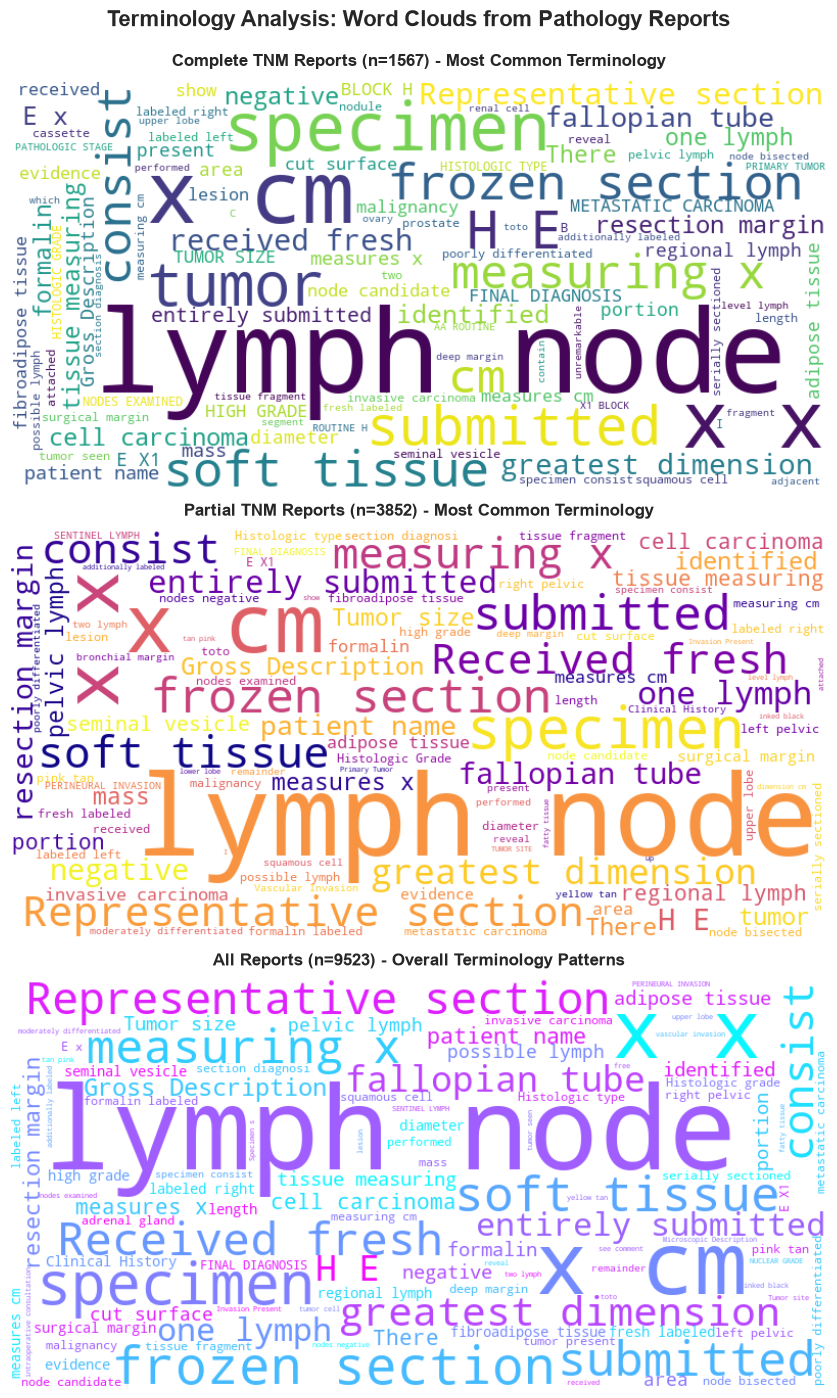


TOP 20 MOST FREQUENT WORDS IN EACH CATEGORY

>>> COMPLETE TNM REPORTS - Top 20 Words:
   1. lymph node           - Frequency: 1.0000
   2. x cm                 - Frequency: 0.5086
   3. x x                  - Frequency: 0.4277
   4. specimen             - Frequency: 0.2923
   5. tumor                - Frequency: 0.2278
   6. submitted            - Frequency: 0.1789
   7. H E                  - Frequency: 0.1695
   8. soft tissue          - Frequency: 0.1508
   9. frozen section       - Frequency: 0.1496
  10. cm                   - Frequency: 0.1351
  11. measuring x          - Frequency: 0.1312
  12. consist              - Frequency: 0.1291
  13. Representative section - Frequency: 0.1220
  14. received fresh       - Frequency: 0.1155
  15. greatest dimension   - Frequency: 0.1054
  16. fallopian tube       - Frequency: 0.1013
  17. identified           - Frequency: 0.0892
  18. E x                  - Frequency: 0.0880
  19. resection margin     - Frequency: 0.0822
  20. cell carcino

In [29]:
# ===== DISPLAY WORD CLOUDS =====
# Create figure with three subplots to display all word clouds side by side
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Terminology Analysis: Word Clouds from Pathology Reports', 
             fontsize=16, fontweight='bold', y=0.995)

# ===== WORD CLOUD 1: COMPLETE TNM REPORTS =====
# Shows most common terms in high-quality reports with complete staging information
ax1 = axes[0]
if wc_complete is not None:
    ax1.imshow(wc_complete, interpolation='bilinear')
    ax1.set_title(f'Complete TNM Reports (n={len(rows_with_complete_tnm)}) - Most Common Terminology', 
                  fontsize=12, fontweight='bold', pad=10)
else:
    ax1.text(0.5, 0.5, 'No complete TNM data available for word cloud', 
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Complete TNM Reports - No Data', fontsize=12, fontweight='bold', pad=10)
ax1.axis('off')

# ===== WORD CLOUD 2: PARTIAL TNM REPORTS =====
# Shows most common terms in reports with partial TNM staging information
ax2 = axes[1]
if wc_partial is not None:
    ax2.imshow(wc_partial, interpolation='bilinear')
    ax2.set_title(f'Partial TNM Reports (n={len(rows_with_partial_tnm)}) - Most Common Terminology', 
                  fontsize=12, fontweight='bold', pad=10)
else:
    ax2.text(0.5, 0.5, 'No partial TNM data available for word cloud', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Partial TNM Reports - No Data', fontsize=12, fontweight='bold', pad=10)
ax2.axis('off')

# ===== WORD CLOUD 3: ALL REPORTS =====
# Shows most common terms across entire dataset (all 9,523 reports)
# This provides baseline understanding of overall pathology vocabulary
ax3 = axes[2]
if wc_all is not None:
    ax3.imshow(wc_all, interpolation='bilinear')
    ax3.set_title(f'All Reports (n={len(df_processed)}) - Overall Terminology Patterns', 
                  fontsize=12, fontweight='bold', pad=10)
else:
    ax3.text(0.5, 0.5, 'No report data available for word cloud', 
             ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('All Reports - No Data', fontsize=12, fontweight='bold', pad=10)
ax3.axis('off')

plt.tight_layout()
plt.show()

# ===== EXTRACT TOP WORDS FOR ANALYSIS =====
# Display the 20 most frequent words in each category for quantitative analysis
# Using words_ dictionary from WordCloud objects which stores word frequency data
print("\n" + "="*80)
print("TOP 20 MOST FREQUENT WORDS IN EACH CATEGORY")
print("="*80)

# Extract frequency data from word clouds using words_ attribute
# This dictionary maps each word to its frequency in the corpus
complete_freq = wc_complete.words_ if wc_complete else {}
partial_freq = wc_partial.words_ if wc_partial else {}
all_freq = wc_all.words_ if wc_all else {}

# Sort and display top 20 for complete TNM
print("\n>>> COMPLETE TNM REPORTS - Top 20 Words:")
complete_top = sorted(complete_freq.items(), key=lambda x: x[1], reverse=True)[:20]
for i, (word, freq) in enumerate(complete_top, 1):
    print(f"  {i:2d}. {word:20s} - Frequency: {freq:.4f}")

# Sort and display top 20 for partial TNM
print("\n>>> PARTIAL TNM REPORTS - Top 20 Words:")
partial_top = sorted(partial_freq.items(), key=lambda x: x[1], reverse=True)[:20]
for i, (word, freq) in enumerate(partial_top, 1):
    print(f"  {i:2d}. {word:20s} - Frequency: {freq:.4f}")

# Sort and display top 20 for all reports
print("\n>>> ALL REPORTS - Top 20 Words:")
all_top = sorted(all_freq.items(), key=lambda x: x[1], reverse=True)[:20]
for i, (word, freq) in enumerate(all_top, 1):
    print(f"  {i:2d}. {word:20s} - Frequency: {freq:.4f}")

print("\n" + "="*80)
print("Word cloud generation completed successfully!")
print("="*80)

## Section 8: Save Processed Results

**Objective**: Export TNM-extracted data and statistics in multiple CSV formats for downstream analysis

**What happens here**:
- **File 1**: TCGA_Complete_TNM_Extraction.csv
  - Contains 2,902 reports with complete T, N, M values
  - Use for studies requiring full staging classification
  
- **File 2**: TCGA_Partial_TNM_Extraction.csv
  - Contains 4,623 reports with at least one TNM component
  - Includes boolean flags showing which components were found
  
- **File 3**: TCGA_Reports_with_TNM_Extraction.csv
  - Contains all 9,523 reports with TNM metadata
  - Includes all boolean flags for filtering and quality assessment
  
- **File 4**: TCGA_TNM_Extraction_Summary.csv
  - Contains key metrics and coverage statistics
  - Quick reference for analysis performance

- Display export summary showing file paths and record counts

In [30]:
# ============================================================================
# SECTION 8: SAVE PROCESSED RESULTS TO CSV FILES
# ============================================================================
# Export TNM-extracted data in multiple formats for downstream analysis:
# 1. Complete TNM extraction only
# 2. Partial TNM extraction only
# 3. Full dataset with TNM metadata
# 4. Summary statistics

print("Exporting processed results to CSV files...\n")

# ===== EXPORT 1: COMPLETE TNM EXTRACTION =====
# File contains only reports where T, N, and M were all successfully extracted
# Use case: Studies requiring complete staging information
complete_tnm_df = df_processed[df_processed['has_complete_TNM']][
    ['patient_filename', 'T_stage', 'N_stage', 'M_stage', 'TNM_raw']
].copy()

complete_tnm_df.to_csv('TCGA_Complete_TNM_Extraction.csv', index=False)
print(f"✓ Exported {len(complete_tnm_df)} rows with complete TNM extraction")
print(f"  File: TCGA_Complete_TNM_Extraction.csv\n")

# ===== EXPORT 2: PARTIAL TNM EXTRACTION =====
# File contains reports with at least one TNM component but not all three
# Use case: Broader analysis when some staging info is acceptable
partial_tnm_df = df_processed[
    ((df_processed['has_T'] | df_processed['has_N'] | df_processed['has_M']) & 
     ~df_processed['has_complete_TNM'])
][['patient_filename', 'T_stage', 'N_stage', 'M_stage', 'TNM_raw', 'has_T', 'has_N', 'has_M']].copy()

partial_tnm_df.to_csv('TCGA_Partial_TNM_Extraction.csv', index=False)
print(f"✓ Exported {len(partial_tnm_df)} rows with partial TNM extraction")
print(f"  File: TCGA_Partial_TNM_Extraction.csv\n")

# ===== EXPORT 3: FULL PROCESSED DATASET =====
# File contains all 9,523 reports with complete TNM metadata
# Includes boolean flags and raw extraction data for maximum flexibility
full_dataset_df = df_processed[[
    'patient_filename', 'T_stage', 'N_stage', 'M_stage', 'TNM_raw',
    'has_T', 'has_N', 'has_M', 'has_complete_TNM'
]].copy()

full_dataset_df.to_csv('TCGA_Reports_with_TNM_Extraction.csv', index=False)
print(f"✓ Exported {len(full_dataset_df)} rows with full TNM metadata")
print(f"  File: TCGA_Reports_with_TNM_Extraction.csv\n")

# ===== EXPORT 4: SUMMARY STATISTICS =====
# File contains key metrics and coverage statistics for quick reference
summary_stats_export = {
    'Metric': [
        'Total Reports',
        'Complete TNM Extraction',
        'Partial TNM Extraction',
        'No TNM Components',
        'T Stage Coverage (%)',
        'N Stage Coverage (%)',
        'M Stage Coverage (%)',
        'Average Report Length (chars)',
        'Median Report Length (chars)',
        'Max Report Length (chars)',
        'Unique Patients',
        'Duplicate Patients'
    ],
    'Value': [
        len(df_processed),
        len(rows_with_complete_tnm),
        len(rows_with_partial_tnm),
        len(rows_without_tnm),
        round((df_processed['has_T'].sum() / len(df_processed)) * 100, 2),
        round((df_processed['has_N'].sum() / len(df_processed)) * 100, 2),
        round((df_processed['has_M'].sum() / len(df_processed)) * 100, 2),
        round(df_processed['text'].str.len().mean(), 0),
        round(df_processed['text'].str.len().median(), 0),
        df_processed['text'].str.len().max(),
        df_processed['patient_filename'].nunique(),
        len(df_processed) - df_processed['patient_filename'].nunique()
    ]
}

summary_stats_export_df = pd.DataFrame(summary_stats_export)
summary_stats_export_df.to_csv('TCGA_TNM_Extraction_Summary.csv', index=False)
print(f"✓ Exported summary statistics")
print(f"  File: TCGA_TNM_Extraction_Summary.csv\n")

# ===== DISPLAY EXPORT SUMMARY =====
print("\n" + "=" * 80)
print("EXPORT SUMMARY - FILES CREATED")
print("=" * 80)
print(f"\n1. TCGA_Complete_TNM_Extraction.csv")
print(f"   Records: {len(complete_tnm_df):,}")
print(f"   Contains: Complete TNM data (T, N, M all present)")
print(f"\n2. TCGA_Partial_TNM_Extraction.csv")
print(f"   Records: {len(partial_tnm_df):,}")
print(f"   Contains: Partial TNM data (at least one component present)")
print(f"\n3. TCGA_Reports_with_TNM_Extraction.csv")
print(f"   Records: {len(full_dataset_df):,}")
print(f"   Contains: Full dataset with TNM metadata and quality flags")
print(f"\n4. TCGA_TNM_Extraction_Summary.csv")
print(f"   Summary statistics and coverage metrics")
print(f"\nAll files have been successfully exported to the current directory.")
print("=" * 80)

Exporting processed results to CSV files...

✓ Exported 1567 rows with complete TNM extraction
  File: TCGA_Complete_TNM_Extraction.csv

✓ Exported 3852 rows with partial TNM extraction
  File: TCGA_Partial_TNM_Extraction.csv

✓ Exported 9523 rows with full TNM metadata
  File: TCGA_Reports_with_TNM_Extraction.csv

✓ Exported summary statistics
  File: TCGA_TNM_Extraction_Summary.csv


EXPORT SUMMARY - FILES CREATED

1. TCGA_Complete_TNM_Extraction.csv
   Records: 1,567
   Contains: Complete TNM data (T, N, M all present)

2. TCGA_Partial_TNM_Extraction.csv
   Records: 3,852
   Contains: Partial TNM data (at least one component present)

3. TCGA_Reports_with_TNM_Extraction.csv
   Records: 9,523
   Contains: Full dataset with TNM metadata and quality flags

4. TCGA_TNM_Extraction_Summary.csv
   Summary statistics and coverage metrics

All files have been successfully exported to the current directory.


## Section 9: Row-by-Row T / N / M Exploration

**Objective**: Browse extracted T, N, and M rows individually for manual review and validation

**How to use**:
- Each sub-section below is dedicated to one TNM component (T, N, or M)
- Unique stage values are printed so you can pick a target value
- Set `target_value` to the stage you want to inspect (e.g. `"1"`, `"2a"`, `"X"`)
- Set `row_index` to `0` to start at the first matching row, increment to step through them
- The cell prints the patient ID, extracted stage, and the relevant report snippet

In [31]:
# ============================================================================
# SECTION 9A: T STAGE — ROW-BY-ROW BROWSER + CSV EXPORT
# ============================================================================

# ----- 1. Show available T stage values -----
t_rows = df_processed[df_processed['has_T']].copy()
print(f"Total rows with a T stage: {len(t_rows):,}")
print("\nUnique T stage values (sorted):")
print(sorted(t_rows['T_stage'].dropna().unique()))

# ----- 2. Pick a target value and a row index -----
target_T_value = "1"   # <-- change this to the T stage you want to inspect
row_index_T   = 0      # <-- change this to step through rows (0 = first match)

# ----- 3. Filter and display -----
subset_T = t_rows[t_rows['T_stage'] == target_T_value].reset_index(drop=True)
total_T   = len(subset_T)

if total_T == 0:
    print(f"\nNo rows found for T stage = '{target_T_value}'")
elif row_index_T >= total_T:
    print(f"\nrow_index_T ({row_index_T}) exceeds available rows ({total_T}). "
          f"Set it between 0 and {total_T - 1}.")
else:
    row = subset_T.iloc[row_index_T]
    print(f"\n{'='*70}")
    print(f"T stage = '{target_T_value}'  |  Row {row_index_T + 1} of {total_T}")
    print(f"{'='*70}")
    print(f"Patient file : {row['patient_filename']}")
    print(f"T stage      : {row['T_stage']}")
    print(f"N stage      : {row.get('N_stage', 'n/a')}")
    print(f"M stage      : {row.get('M_stage', 'n/a')}")
    print(f"TNM raw      : {row.get('TNM_raw', 'n/a')}")
    print(f"\n--- Report snippet (first 1 000 chars) ---")
    print(str(row['text'])[:1000])

# ----- 4. Save full filtered subset to CSV -----
if total_T > 0:
    csv_T = f"T_stage_{target_T_value}_reports.csv"
    subset_T.to_csv(csv_T, index=False)
    print(f"\n✓ Saved {total_T} rows  →  {csv_T}")

Total rows with a T stage: 5,023

Unique T stage values (sorted):
['1', '1A', '1B', '1C', '2', '2A', '2B', '2C', '3', '3A', '3B', '3C', '4', '4A', '4B', '4C', 'IS', 'X']

T stage = '1'  |  Row 1 of 527
Patient file : TCGA-BP-5195.25c0b433-5557-4165-922e-2c1eac9c26f0
T stage      : 1
N stage      : nan
M stage      : nan
TNM raw      : nan

--- Report snippet (first 1 000 chars) ---
Date of Recelpt: Clinical Diagnosis & History: Incidental 3 cm left upper pole renal mass. Specimens Submitted: 1: Kidney, Left Upper Pole; Partial Nephrectomy. DIAGNOSIS: 1. Kidney, Left Upper Pole; Partial Nephrectomy: Tumor Type: Renal cell carcinoma - Conventional (clear cell) type. Fuhrman Nuclear Grade: Nuclear grade II/IV. Tumor Size: Greatest diameter is 2.4 cm. Local Invasion (for renal cortical types): Not Identified. Renal Vein Invasion: Not identified. Surgical Margins: Free of tumor. Non-Neoplastic Kidney: shows focal chronic inflammation and focal superficial glomerulosclerosis. Adrenal Gland: 

In [32]:
# ============================================================================
# SECTION 9B: N STAGE — ROW-BY-ROW BROWSER + CSV EXPORT
# ============================================================================

# ----- 1. Show available N stage values -----
n_rows = df_processed[df_processed['has_N']].copy()
print(f"Total rows with an N stage: {len(n_rows):,}")
print("\nUnique N stage values (sorted):")
print(sorted(n_rows['N_stage'].dropna().unique()))

# ----- 2. Pick a target value and a row index -----
target_N_value = "0"   # <-- change this to the N stage you want to inspect
row_index_N   = 0      # <-- change this to step through rows (0 = first match)

# ----- 3. Filter and display -----
subset_N = n_rows[n_rows['N_stage'] == target_N_value].reset_index(drop=True)
total_N   = len(subset_N)

if total_N == 0:
    print(f"\nNo rows found for N stage = '{target_N_value}'")
elif row_index_N >= total_N:
    print(f"\nrow_index_N ({row_index_N}) exceeds available rows ({total_N}). "
          f"Set it between 0 and {total_N - 1}.")
else:
    row = subset_N.iloc[row_index_N]
    print(f"\n{'='*70}")
    print(f"N stage = '{target_N_value}'  |  Row {row_index_N + 1} of {total_N}")
    print(f"{'='*70}")
    print(f"Patient file : {row['patient_filename']}")
    print(f"T stage      : {row.get('T_stage', 'n/a')}")
    print(f"N stage      : {row['N_stage']}")
    print(f"M stage      : {row.get('M_stage', 'n/a')}")
    print(f"TNM raw      : {row.get('TNM_raw', 'n/a')}")
    print(f"\n--- Report snippet (first 1 000 chars) ---")
    print(str(row['text'])[:1000])

# ----- 4. Save full filtered subset to CSV -----
if total_N > 0:
    csv_N = f"N_stage_{target_N_value}_reports.csv"
    subset_N.to_csv(csv_N, index=False)
    print(f"\n✓ Saved {total_N} rows  →  {csv_N}")

Total rows with an N stage: 2,903

Unique N stage values (sorted):
['0', '1', '1A', '1B', '1C', '2', '2A', '2B', '2C', '3', '3A', '3B', 'X']

N stage = '0'  |  Row 1 of 228
Patient file : TCGA-A6-3808.e1505f65-72ef-438d-a5e1-93ed8bf6635d
T stage      : 3
N stage      : 0
M stage      : X
TNM raw      : nan

--- Report snippet (first 1 000 chars) ---
SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP DIAGNOSIS: Carcinoma right colon. GROSS DESCRIPTION. Received fresh for tissue procurement labeled "right. colon". is a previously unopened 15 cm. segment of proximal right. colon with attached 15 cm. distal ileum surfaced by smooth to. scabrous tan pink serosa with a copious amount of attached. mesocolon. and mesentery. No appendix is present. The proximal and distal. margins measure 3.2 and 5.2 cm. in circumference respectively. On. opening there is a well circumscribed, 4.4 x 4.0 cm. rubbery tan. white-red tumor mass within the cecal pouch, 1 cm. distal to the. ileocecal valve. A portion of t

In [33]:
# ============================================================================
# SECTION 9C: M STAGE — ROW-BY-ROW BROWSER + CSV EXPORT
# ============================================================================

# ----- 1. Show available M stage values -----
m_rows = df_processed[df_processed['has_M']].copy()
print(f"Total rows with an M stage: {len(m_rows):,}")
print("\nUnique M stage values (sorted):")
print(sorted(m_rows['M_stage'].dropna().unique()))

# ----- 2. Pick a target value and a row index -----
target_M_value = "0"   # <-- change this to the M stage you want to inspect
row_index_M   = 0      # <-- change this to step through rows (0 = first match)

# ----- 3. Filter and display -----
subset_M = m_rows[m_rows['M_stage'] == target_M_value].reset_index(drop=True)
total_M   = len(subset_M)

if total_M == 0:
    print(f"\nNo rows found for M stage = '{target_M_value}'")
elif row_index_M >= total_M:
    print(f"\nrow_index_M ({row_index_M}) exceeds available rows ({total_M}). "
          f"Set it between 0 and {total_M - 1}.")
else:
    row = subset_M.iloc[row_index_M]
    print(f"\n{'='*70}")
    print(f"M stage = '{target_M_value}'  |  Row {row_index_M + 1} of {total_M}")
    print(f"{'='*70}")
    print(f"Patient file : {row['patient_filename']}")
    print(f"T stage      : {row.get('T_stage', 'n/a')}")
    print(f"N stage      : {row.get('N_stage', 'n/a')}")
    print(f"M stage      : {row['M_stage']}")
    print(f"TNM raw      : {row.get('TNM_raw', 'n/a')}")
    print(f"\n--- Report snippet (first 1 000 chars) ---")
    print(str(row['text'])[:1000])

# ----- 4. Save full filtered subset to CSV -----
if total_M > 0:
    csv_M = f"M_stage_{target_M_value}_reports.csv"
    subset_M.to_csv(csv_M, index=False)
    print(f"\n✓ Saved {total_M} rows  →  {csv_M}")

Total rows with an M stage: 2,640

Unique M stage values (sorted):
['0', '1', 'X']

M stage = '0'  |  Row 1 of 108
Patient file : TCGA-HS-A5N8.23C57E99-5BF2-4CD2-AC62-E58D3FBBF273
T stage      : 2B
N stage      : X
M stage      : 0
TNM raw      : nan

--- Report snippet (first 1 000 chars) ---
Sample Type TUMOUR. Diagnosis. Leiomyosarcoma. Year of Sample Collection. Age at Sample Collection (yrs). Days to Procedure Date. Days to Diagnosis. Type of Procedure. RESECT. Site of Tissue/Primary (Histology). Uterus, Ovary. Tumour Size (cm). 10. Histology. Leiomyosarcoma. Grade/Differentiation. X. Pathological T. T2b. Pathological N. NX. Clinical M. M0. Histology Comments. Sample Type BUFFY. Year of Sample Collection. Age at Sample Collection (yrs). Days to Procedure Date. Days to Diagnosis.

✓ Saved 108 rows  →  M_stage_0_reports.csv


In [34]:
# ============================================================================
# SECTION 9D: FULL REPORT READER
# ============================================================================
# Set tnm_filter to narrow down which reports to browse.
# Then optionally filter by specific T, N, or M values.
# Increment row_index to step through matching reports one by one.
#
# tnm_filter : "complete" | "partial" | "none" | "all"
# filter_T   : e.g. "1", "2a", "X"  — or None to skip T filtering
# filter_N   : e.g. "0", "1b"       — or None to skip N filtering
# filter_M   : e.g. "0", "1"        — or None to skip M filtering

tnm_filter = "complete"   # "complete" | "partial" | "none" | "all"
filter_T   = None         # e.g. "1"  — set to None to ignore
filter_N   = None         # e.g. "0"  — set to None to ignore
filter_M   = None         # e.g. "0"  — set to None to ignore
row_index  = 0            # increment to step through matching reports

# ---- build subset by TNM type -----------------------------------------------
if tnm_filter == "complete":
    subset = df_processed[df_processed['has_complete_TNM']].reset_index(drop=True)
elif tnm_filter == "partial":
    subset = df_processed[
        (df_processed['has_T'] | df_processed['has_N'] | df_processed['has_M']) &
        ~df_processed['has_complete_TNM']
    ].reset_index(drop=True)
elif tnm_filter == "none":
    subset = df_processed[
        ~df_processed['has_T'] & ~df_processed['has_N'] & ~df_processed['has_M']
    ].reset_index(drop=True)
else:  # "all"
    subset = df_processed.reset_index(drop=True)

# ---- apply T / N / M value filters ------------------------------------------
active_filters = []
if filter_T is not None:
    subset = subset[subset['T_stage'] == filter_T].reset_index(drop=True)
    active_filters.append(f"T={filter_T}")
if filter_N is not None:
    subset = subset[subset['N_stage'] == filter_N].reset_index(drop=True)
    active_filters.append(f"N={filter_N}")
if filter_M is not None:
    subset = subset[subset['M_stage'] == filter_M].reset_index(drop=True)
    active_filters.append(f"M={filter_M}")

filter_label = f"TNM type='{tnm_filter}'" + (
    "  |  " + ", ".join(active_filters) if active_filters else ""
)

total = len(subset)

# ---- display ----------------------------------------------------------------
if total == 0:
    print(f"No reports found for: {filter_label}")
    # Show available values to help pick valid ones
    base = df_processed if tnm_filter == "all" else subset
    print(f"\nAvailable T values: {sorted(df_processed['T_stage'].dropna().unique())}")
    print(f"Available N values: {sorted(df_processed['N_stage'].dropna().unique())}")
    print(f"Available M values: {sorted(df_processed['M_stage'].dropna().unique())}")
elif row_index < 0 or row_index >= total:
    print(f"row_index must be between 0 and {total - 1}  ({filter_label})")
else:
    row = subset.iloc[row_index]
    print(f"{filter_label}  |  Report {row_index + 1} of {total}")
    print("=" * 70)
    print(f"Patient file : {row['patient_filename']}")
    print(f"T stage      : {row.get('T_stage', 'n/a')}")
    print(f"N stage      : {row.get('N_stage', 'n/a')}")
    print(f"M stage      : {row.get('M_stage', 'n/a')}")
    print(f"TNM raw      : {row.get('TNM_raw', 'n/a')}")
    print("=" * 70)
    print("\nFULL REPORT TEXT:\n")
    print(str(row['text']))

TNM type='complete'  |  Report 1 of 1567
Patient file : TCGA-A6-3808.e1505f65-72ef-438d-a5e1-93ed8bf6635d
T stage      : 3
N stage      : 0
M stage      : X
TNM raw      : nan

FULL REPORT TEXT:

SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP DIAGNOSIS: Carcinoma right colon. GROSS DESCRIPTION. Received fresh for tissue procurement labeled "right. colon". is a previously unopened 15 cm. segment of proximal right. colon with attached 15 cm. distal ileum surfaced by smooth to. scabrous tan pink serosa with a copious amount of attached. mesocolon. and mesentery. No appendix is present. The proximal and distal. margins measure 3.2 and 5.2 cm. in circumference respectively. On. opening there is a well circumscribed, 4.4 x 4.0 cm. rubbery tan. white-red tumor mass within the cecal pouch, 1 cm. distal to the. ileocecal valve. A portion of tumor and a portion of normal are. submitted for tissue procurement as requested. On sectioning, the. tumor has a maximal thickness of 1.1 cm., grossly exten

## Section 10: Enhanced TNM Extraction (Track A)

**Objective**: Boost extraction coverage by adding keyword/count-based fallbacks for N and M stages, handling Dukes staging, and recognising post-treatment (yp/yc) prefixes.

**Improvements over base regex:**
- **N stage**: node-count patterns (`3/12 nodes positive` → N1), negative/positive keyword blocks
- **M stage**: broader keyword coverage (`no distant disease`, `metastases to liver` etc.)
- **Dukes/Astler-Coller → TNM**: maps colorectal alternative staging to T/N/M
- **Prefix handling**: `ypT`, `ycN`, `rcT` (post-treatment, recurrence) now normalised
- **Result**: compare old vs enhanced coverage side-by-side

In [ ]:

# ============================================================================
# SECTION 10: ENHANCED TNM EXTRACTION
# ============================================================================

import re

# ── Dukes / Astler-Coller → approximate TNM mapping ──────────────────────────
DUKES_TO_TNM = {
    'A':  ('1', '0', '0'),   # confined to bowel wall, no nodes, no mets
    'B':  ('3', '0', '0'),   # through wall, no nodes, no mets
    'C':  ('3', '1', '0'),   # any T, positive nodes, no mets
    'C1': ('3', '1', '0'),
    'C2': ('4', '2', '0'),
    'D':  ('4', '1', '1'),   # distant metastasis
}

# Astler-Coller stages
ASTLER_COLLER_TO_TNM = {
    'A':  ('1', '0', '0'),
    'B1': ('2', '0', '0'),
    'B2': ('3', '0', '0'),
    'C1': ('2', '1', '0'),
    'C2': ('3', '1', '0'),
    'D':  ('4', '1', '1'),
}


def _clean_prefix(val: str) -> str:
    """Strip pathological/clinical/post-treatment prefix from a stage value."""
    return re.sub(r'^[PCYR]+', '', val, flags=re.IGNORECASE).upper()


def extract_tnm_enhanced(text: str) -> dict:
    """
    Enhanced TNM extractor.
    Priority order:
      1. Combined TNM regex (same as base)
      2. Individual component regex (same as base, with ypT/ycN support)
      3. Keyword + count-based N-stage fallback
      4. Keyword-based M-stage fallback
      5. Dukes / Astler-Coller staging conversion
    """
    result = {
        'T_stage': None, 'N_stage': None, 'M_stage': None,
        'TNM_raw': None, 'has_T': False, 'has_N': False, 'has_M': False,
        'source': 'none',
    }

    u = str(text).upper()

    # ── 1. COMBINED TNM PATTERN ───────────────────────────────────────────────
    combined = re.search(
        r'(?<![A-Z])'
        r'([PCYR]{0,2}T(?:IS|X|[0-4][A-C]?))'
        r'[\s,;/]*'
        r'([PCYR]{0,2}N(?:X|[0-3][A-C]?))'
        r'[\s,;/]*'
        r'([PCYR]{0,2}M[01X])'
        r'(?![A-Z0-9])',
        u
    )
    if combined:
        result['TNM_raw'] = combined.group(0).strip()
        t = re.search(r'T(IS|X|[0-4][A-C]?)', combined.group(1))
        n = re.search(r'N(X|[0-3][A-C]?)', combined.group(2))
        m = re.search(r'M([01X])', combined.group(3))
        if t: result['T_stage'] = t.group(1); result['has_T'] = True
        if n: result['N_stage'] = n.group(1); result['has_N'] = True
        if m: result['M_stage'] = m.group(1); result['has_M'] = True
        result['source'] = 'combined_regex'
        return result

    # ── 2. INDIVIDUAL COMPONENT REGEX (supports yp/yc/rc prefixes) ───────────
    t_m = re.search(r'(?<![A-Z])([PCYR]{0,2}T)(IS|X|[0-4][A-C]?)(?![A-BD-LO-WY-Z0-9])', u)
    if t_m:
        result['T_stage'] = t_m.group(2)
        result['has_T'] = True

    n_m = re.search(r'(?<![A-Z])([PCYR]{0,2}N)(X|[0-3][A-C]?)(?![A-BD-LO-WY-Z0-9])', u)
    if n_m:
        result['N_stage'] = n_m.group(2)
        result['has_N'] = True

    m_m = re.search(r'(?<![A-Z])([PCYR]{0,2}M)([01X])(?![A-Z0-9])', u)
    if m_m:
        result['M_stage'] = m_m.group(2)
        result['has_M'] = True

    if result['has_T'] or result['has_N'] or result['has_M']:
        result['source'] = 'individual_regex'

    # ── 3. KEYWORD / COUNT-BASED N-STAGE FALLBACK ────────────────────────────
    if not result['has_N']:
        lower = text.lower()

        # Pattern: "X of Y nodes positive/involved/metastatic"
        count_pat = re.search(
            r'(\d+)\s*(?:of|out of|/)\s*(\d+)\s*(?:lymph\s*)?nodes?\s*'
            r'(?:positive|involved|metastatic|with\s*metastasis)',
            lower
        )
        if count_pat:
            pos = int(count_pat.group(1))
            if pos == 0:   result['N_stage'] = '0'
            elif pos <= 3: result['N_stage'] = '1'
            elif pos <= 9: result['N_stage'] = '2'
            else:          result['N_stage'] = '3'
            result['has_N'] = True
            result['source'] = result['source'] + '+N_count' if result['source'] != 'none' else 'N_count'
        else:
            # Keyword N0 signals
            n0_kw = [
                'no lymph node', 'lymph nodes negative', 'no nodal involvement',
                'nodes are negative', 'node negative', 'lymph nodes: negative',
                'no regional lymph node', 'lymph node metastasis: none',
                'negative lymph nodes', 'lymph nodes free', '0 lymph nodes positive',
                'regional nodes: negative', 'no node involvement',
            ]
            if any(kw in lower for kw in n0_kw):
                result['N_stage'] = '0'; result['has_N'] = True
                result['source'] = result['source'] + '+N_kw' if result['source'] != 'none' else 'N_keyword'
            else:
                # Keyword N1+ signals (no count available)
                n1_kw = [
                    'lymph node metastasis', 'lymph node involvement',
                    'positive lymph node', 'nodal metastasis', 'nodes positive',
                    'nodal involvement', 'lymph node positive', 'node metastasis',
                    'metastatic lymph node', 'lymph nodes positive',
                    'regional lymph node metastasis',
                ]
                if any(kw in lower for kw in n1_kw):
                    result['N_stage'] = '1'; result['has_N'] = True
                    result['source'] = result['source'] + '+N_kw' if result['source'] != 'none' else 'N_keyword'

    # ── 4. KEYWORD-BASED M-STAGE FALLBACK ────────────────────────────────────
    if not result['has_M']:
        lower = text.lower()

        m0_kw = [
            'no metastasis', 'no distant metastasis', 'no evidence of metastasis',
            'no distant spread', 'no evidence of distant', 'metastasis: none',
            'metastasis: not identified', 'no distant disease', 'distant metastasis: no',
            'no organ metastasis', 'no visceral metastasis', 'm0', 'stage m0',
            'no metastatic disease', 'no distant metastatic',
        ]
        m1_kw = [
            'distant metastasis', 'distant metastases', 'metastatic disease',
            'metastases to', 'metastatic spread', 'visceral metastasis',
            'organ metastasis', 'liver metastasis', 'lung metastasis',
            'bone metastasis', 'brain metastasis', 'peritoneal metastasis',
        ]
        if any(kw in lower for kw in m0_kw):
            result['M_stage'] = '0'; result['has_M'] = True
            result['source'] = result['source'] + '+M_kw' if result['source'] != 'none' else 'M_keyword'
        elif any(kw in lower for kw in m1_kw):
            result['M_stage'] = '1'; result['has_M'] = True
            result['source'] = result['source'] + '+M_kw' if result['source'] != 'none' else 'M_keyword'

    # ── 5. DUKES / ASTLER-COLLER FALLBACK ────────────────────────────────────
    if not (result['has_T'] and result['has_N'] and result['has_M']):
        lower = text.lower()

        # Astler-Coller (try first — more specific)
        ac_match = re.search(
            r'astler[- ]coller\s*(?:stage\s*)?([abcd][12]?)',
            lower
        )
        if not ac_match:
            ac_match = re.search(r'\b(?:stage\s*)?([abcd][12])\b', lower)

        if ac_match:
            stage_key = ac_match.group(1).upper()
            tnm = ASTLER_COLLER_TO_TNM.get(stage_key)
            if tnm:
                if not result['has_T']: result['T_stage'] = tnm[0]; result['has_T'] = True
                if not result['has_N']: result['N_stage'] = tnm[1]; result['has_N'] = True
                if not result['has_M']: result['M_stage'] = tnm[2]; result['has_M'] = True
                result['source'] = result['source'] + '+AstlerColler' if result['source'] != 'none' else 'AstlerColler'
        else:
            # Dukes
            dukes_match = re.search(
                r'dukes[\'s\s]*(?:stage\s*)?([abcd][12]?)',
                lower
            )
            if not dukes_match:
                dukes_match = re.search(r'\bdukes\s+([a-d])\b', lower)
            if dukes_match:
                stage_key = dukes_match.group(1).upper()
                tnm = DUKES_TO_TNM.get(stage_key)
                if tnm:
                    if not result['has_T']: result['T_stage'] = tnm[0]; result['has_T'] = True
                    if not result['has_N']: result['N_stage'] = tnm[1]; result['has_N'] = True
                    if not result['has_M']: result['M_stage'] = tnm[2]; result['has_M'] = True
                    result['source'] = result['source'] + '+Dukes' if result['source'] != 'none' else 'Dukes'

    return result


# ── Apply enhanced extraction ─────────────────────────────────────────────────
print("Applying enhanced TNM extraction to all 9,523 reports...")

df_reports = pd.read_csv('TCGA_Reports.csv')
df_reports['text_upper'] = df_reports['text'].str.upper()

enhanced_results = df_reports['text'].apply(extract_tnm_enhanced)

df_enhanced = df_reports[['patient_filename', 'text']].copy()
df_enhanced['T_stage']   = enhanced_results.apply(lambda x: x['T_stage'])
df_enhanced['N_stage']   = enhanced_results.apply(lambda x: x['N_stage'])
df_enhanced['M_stage']   = enhanced_results.apply(lambda x: x['M_stage'])
df_enhanced['TNM_raw']   = enhanced_results.apply(lambda x: x['TNM_raw'])
df_enhanced['has_T']     = enhanced_results.apply(lambda x: x['has_T'])
df_enhanced['has_N']     = enhanced_results.apply(lambda x: x['has_N'])
df_enhanced['has_M']     = enhanced_results.apply(lambda x: x['has_M'])
df_enhanced['source']    = enhanced_results.apply(lambda x: x['source'])
df_enhanced['has_complete_TNM'] = df_enhanced['has_T'] & df_enhanced['has_N'] & df_enhanced['has_M']

total = len(df_enhanced)
print(f"\n{'='*60}")
print(f"{'METRIC':<35} {'BASELINE':>10} {'ENHANCED':>10} {'DELTA':>8}")
print(f"{'='*60}")

baseline = pd.read_csv('TCGA_Reports_with_TNM_Extraction.csv')
b_T = baseline['has_T'].sum(); e_T = df_enhanced['has_T'].sum()
b_N = baseline['has_N'].sum(); e_N = df_enhanced['has_N'].sum()
b_M = baseline['has_M'].sum(); e_M = df_enhanced['has_M'].sum()
b_C = baseline['has_complete_TNM'].sum(); e_C = df_enhanced['has_complete_TNM'].sum()

for label, b, e in [('T stage found', b_T, e_T), ('N stage found', b_N, e_N),
                     ('M stage found', b_M, e_M), ('Complete TNM', b_C, e_C)]:
    delta = e - b
    print(f"  {label:<33} {b:>10,} {e:>10,} {delta:>+8,}")

print(f"\n  T coverage : {b_T/total*100:.1f}%  →  {e_T/total*100:.1f}%")
print(f"  N coverage : {b_N/total*100:.1f}%  →  {e_N/total*100:.1f}%")
print(f"  M coverage : {b_M/total*100:.1f}%  →  {e_M/total*100:.1f}%")
print(f"  Complete   : {b_C/total*100:.1f}%  →  {e_C/total*100:.1f}%")
print(f"\n{'─'*60}")
print("Source breakdown:")
print(df_enhanced['source'].value_counts().to_string())


In [ ]:

# ============================================================================
# SECTION 10B: SAVE ENHANCED EXTRACTION RESULTS
# ============================================================================

# Export complete set (all T+N+M present)
enhanced_complete = df_enhanced[df_enhanced['has_complete_TNM']][
    ['patient_filename', 'T_stage', 'N_stage', 'M_stage', 'TNM_raw', 'source']
].copy()
enhanced_complete.to_csv('TCGA_Enhanced_Complete_TNM.csv', index=False)

# Export full dataset with flags
df_enhanced[['patient_filename', 'T_stage', 'N_stage', 'M_stage', 'TNM_raw',
             'has_T', 'has_N', 'has_M', 'has_complete_TNM', 'source']
].to_csv('TCGA_Enhanced_TNM_Extraction.csv', index=False)

print(f"✓ TCGA_Enhanced_Complete_TNM.csv    → {len(enhanced_complete):,} records")
print(f"✓ TCGA_Enhanced_TNM_Extraction.csv  → {len(df_enhanced):,} records")

# ── Visualise coverage improvement ───────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Track A — Enhanced vs Baseline Extraction', fontsize=14, fontweight='bold')

components = ['T Stage', 'N Stage', 'M Stage', 'Complete TNM']
base_pct  = [b_T/total*100, b_N/total*100, b_M/total*100, b_C/total*100]
enh_pct   = [e_T/total*100, e_N/total*100, e_M/total*100, e_C/total*100]

x = np.arange(len(components))
w = 0.35

ax = axes[0]
bars1 = ax.bar(x - w/2, base_pct, w, label='Baseline', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + w/2, enh_pct,  w, label='Enhanced', color='#2ecc71', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(components)
ax.set_ylabel('Coverage (%)'); ax.set_title('Coverage: Baseline vs Enhanced')
ax.legend(); ax.set_ylim(0, 100)
for b in bars1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for b in bars2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# Source breakdown pie
ax2 = axes[1]
src_counts = df_enhanced[df_enhanced['source'] != 'none']['source'].value_counts().head(8)
ax2.pie(src_counts.values, labels=src_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Extraction Source Breakdown')

plt.tight_layout()
plt.show()


## Section 11: Downstream Analysis (Track C)

**Objective**: Turn the extracted staging data into clinical insights.

1. **Cancer-type extraction** — decode TCGA TSS codes to cancer study labels  
2. **Overall stage mapping** — convert T/N/M → AJCC Stage 0-IV  
3. **Stage distribution by cancer type** — stacked bar chart  
4. **T/N/M co-occurrence heatmap** — which T stages pair with which N stages  
5. **Stage proportions** — pie / donut of Stage I-IV across the whole cohort

In [ ]:

# ============================================================================
# SECTION 11A: CANCER TYPE & OVERALL STAGE DERIVATION
# ============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# ── TSS code → TCGA cancer study abbreviation (most common codes) ─────────────
TSS_MAP = {
    'AA':'BLCA','AB':'BLCA','B0':'BLCA','BT':'BLCA','CU':'BLCA','GU':'BLCA',
    'BH':'BRCA','A1':'BRCA','A2':'BRCA','A7':'BRCA','A8':'BRCA','AN':'BRCA',
    'AO':'BRCA','AQ':'BRCA','AR':'BRCA','B6':'BRCA','BH':'BRCA','D8':'BRCA',
    'E2':'BRCA','E9':'BRCA','EW':'BRCA','GM':'BRCA','HN':'BRCA','LD':'BRCA',
    'OL':'BRCA','PL':'BRCA','S3':'BRCA',
    'OR':'CESC','EA':'CESC','FU':'CESC','HM':'CESC','MJ':'CESC',
    'BP':'KIRC','B8':'KIRC','CJ':'KIRC','CW':'KIRC','DV':'KIRC','EU':'KIRC',
    'MH':'KIRC',
    'AK':'KIRP','5N':'KIRP','AL':'KIRP','HE':'KIRP','UZ':'KIRP',
    'BQ':'LIHC','CC':'LIHC','DD':'LIHC','FV':'LIHC','G3':'LIHC','RC':'LIHC',
    'ZH':'LIHC',
    'DK':'LUAD','J2':'LUAD','L4':'LUAD','MG':'LUAD','MP':'LUAD','NJ':'LUAD',
    'O1':'LUAD','OS':'LUAD','OX':'LUAD','UC':'LUAD',
    '18':'LUSC','21':'LUSC','33':'LUSC','34':'LUSC','37':'LUSC','43':'LUSC',
    '56':'LUSC','58':'LUSC','6X':'LUSC','85':'LUSC','94':'LUSC','CN':'LUSC',
    'DJ':'LUSC','HC':'LUSC','XC':'LUSC',
    'AX':'OV','13':'OV','23':'OV','24':'OV','25':'OV','29':'OV','30':'OV',
    '31':'OV','36':'OV','57':'OV','59':'OV','61':'OV','61':'OV',
    'A6':'PRAD','CH':'PRAD','EJ':'PRAD','G9':'PRAD','H9':'PRAD','KK':'PRAD',
    'M7':'PRAD','QQ':'PRAD','V1':'PRAD','XJ':'PRAD','YL':'PRAD',
    '3C':'READ','AG':'READ','DC':'READ','EI':'READ','F5':'READ','G5':'READ',
    'AF':'COAD','A5':'COAD','AH':'COAD','AZ':'COAD','BM':'COAD','D5':'COAD',
    'DM':'COAD','F4':'COAD','NH':'COAD','QG':'COAD','SS':'COAD','T9':'COAD',
    'HT':'STAD','B7':'STAD','BR':'STAD','D7':'STAD','FP':'STAD','HU':'STAD',
    'MX':'STAD','RD':'STAD',
    '02':'GBM','06':'GBM','08':'GBM','12':'GBM','14':'GBM','15':'GBM',
    '16':'GBM','19':'GBM','26':'GBM','27':'GBM','28':'GBM','32':'GBM',
    '41':'GBM','06':'GBM',
    'DX':'THCA','BJ':'THCA','DO':'THCA','EM':'THCA','ET':'THCA','J8':'THCA',
    'KS':'UCEC','AJ':'UCEC','B5':'UCEC','BS':'UCEC','D1':'UCEC','E6':'UCEC',
    '55':'UCEC','BG':'UCEC','DF':'UCEC','EL':'UCEC',
    'CV':'HNSC','BA':'HNSC','BB':'HNSC','BD':'HNSC','CR':'HNSC','CX':'HNSC',
    'D6':'HNSC','F1':'HNSC','HD':'HNSC','IQ':'HNSC','P6':'HNSC','QK':'HNSC',
    'TN':'HNSC','UF':'HNSC','UL':'HNSC',
}

# Load enhanced extraction results
df_analysis = pd.read_csv('TCGA_Enhanced_TNM_Extraction.csv')

# Extract TSS code and map to cancer type
df_analysis['tss_code']    = df_analysis['patient_filename'].str.extract(r'TCGA-([A-Z0-9]{2})-')
df_analysis['cancer_type'] = df_analysis['tss_code'].map(TSS_MAP).fillna('OTHER')

print(f"Reports loaded: {len(df_analysis):,}")
print(f"\nCancer type distribution (mapped):")
ct_counts = df_analysis['cancer_type'].value_counts()
print(ct_counts.to_string())


# ── Overall AJCC stage derivation ─────────────────────────────────────────────
def tnm_to_ajcc_stage(row):
    T = str(row.get('T_stage', '') or '').upper()
    N = str(row.get('N_stage', '') or '').upper()
    M = str(row.get('M_stage', '') or '').upper()
    if not (T and N and M):
        return 'Unknown'
    if M == '1':  return 'Stage IV'
    if T == 'IS' and N == '0': return 'Stage 0'
    if T in ('0','1') and N == '0': return 'Stage I'
    if T == '2' and N == '0':   return 'Stage IIA'
    if T == '1' and N in ('1','1A','1B'): return 'Stage IIA'
    if T == '2' and N in ('1','1A','1B'): return 'Stage IIB'
    if T == '3' and N == '0':   return 'Stage IIB'
    if T in ('3','4') and N in ('1','2'): return 'Stage IIIA'
    if N == '3':  return 'Stage IIIC'
    if T == '4':  return 'Stage IIIB'
    if N == '2':  return 'Stage III'
    if T == '1':  return 'Stage I'
    if T == '2':  return 'Stage II'
    if T == '3':  return 'Stage III'
    return 'Unknown'

complete_mask = df_analysis['has_complete_TNM']
df_complete   = df_analysis[complete_mask].copy()
df_complete['ajcc_stage'] = df_complete.apply(tnm_to_ajcc_stage, axis=1)

print(f"\nOverall AJCC stage distribution ({len(df_complete):,} complete records):")
print(df_complete['ajcc_stage'].value_counts().sort_index().to_string())


In [ ]:

# ============================================================================
# SECTION 11B: VISUALISATIONS — STAGE DISTRIBUTION & CO-OCCURRENCE
# ============================================================================

sns.set_style("whitegrid")
fig = plt.figure(figsize=(20, 18))
fig.suptitle('TCGA Downstream Analysis — Cancer Stage Insights', fontsize=16, fontweight='bold', y=1.01)

# ── PLOT 1: Overall AJCC stage donut ─────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
stage_order = ['Stage 0','Stage I','Stage IIA','Stage IIB','Stage II',
               'Stage IIIA','Stage IIIB','Stage IIIC','Stage III','Stage IV','Unknown']
stage_counts = df_complete['ajcc_stage'].value_counts().reindex(
    [s for s in stage_order if s in df_complete['ajcc_stage'].values], fill_value=0
)
colors_stage = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(stage_counts)))
wedges, texts, autotexts = ax1.pie(
    stage_counts.values, labels=stage_counts.index,
    autopct='%1.1f%%', colors=colors_stage, startangle=90,
    wedgeprops=dict(width=0.6)
)
for t in texts: t.set_fontsize(7)
for a in autotexts: a.set_fontsize(7)
ax1.set_title('Overall AJCC Stage\n(complete TNM records)', fontweight='bold', fontsize=10)

# ── PLOT 2: T/N co-occurrence heatmap ────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
t_order = ['IS','0','1','1A','1B','1C','2','2A','2B','2C','3','3A','3B','3C','4','4A','4B','4C','X']
n_order = ['X','0','0A','0B','0C','1','1A','1B','1C','2','2A','2B','2C','3','3A','3B','3C']
t_vals = [v for v in t_order if v in df_complete['T_stage'].values]
n_vals = [v for v in n_order if v in df_complete['N_stage'].values]
if t_vals and n_vals:
    heatmap_data = pd.crosstab(df_complete['T_stage'], df_complete['N_stage'])
    heatmap_data = heatmap_data.reindex(index=t_vals, columns=n_vals, fill_value=0)
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues', ax=ax2,
                linewidths=0.5, linecolor='white', annot_kws={'size': 7})
    ax2.set_title('T vs N Stage Co-occurrence', fontweight='bold', fontsize=10)
    ax2.set_xlabel('N Stage'); ax2.set_ylabel('T Stage')

# ── PLOT 3: Top-15 cancer types by report count ───────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
top_types = ct_counts.head(15)
bars = ax3.barh(top_types.index[::-1], top_types.values[::-1], color='#3498db', alpha=0.85)
ax3.set_xlabel('Number of Reports')
ax3.set_title('Top 15 Cancer Types\n(by report count)', fontweight='bold', fontsize=10)
for b in bars:
    ax3.text(b.get_width()+5, b.get_y()+b.get_height()/2,
             str(int(b.get_width())), va='center', fontsize=7)

# ── PLOT 4: Complete TNM rate by cancer type (top 12) ─────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
type_complete = df_analysis.groupby('cancer_type').agg(
    total=('has_complete_TNM', 'count'),
    complete=('has_complete_TNM', 'sum')
).reset_index()
type_complete['pct'] = (type_complete['complete'] / type_complete['total'] * 100).round(1)
type_complete = type_complete[type_complete['total'] >= 50].sort_values('pct', ascending=True).tail(12)
ax4.barh(type_complete['cancer_type'], type_complete['pct'], color='#2ecc71', alpha=0.85)
ax4.set_xlabel('Complete TNM Rate (%)')
ax4.set_title('Complete TNM Rate\nby Cancer Type (≥50 reports)', fontweight='bold', fontsize=10)
ax4.set_xlim(0, 100)
for i, (_, row) in enumerate(type_complete.iterrows()):
    ax4.text(row['pct']+0.5, i, f"{row['pct']:.1f}%", va='center', fontsize=8)

# ── PLOT 5: T stage distribution stacked by cancer type (top 8) ───────────────
ax5 = fig.add_subplot(3, 3, 5)
top8 = ct_counts[ct_counts.index != 'OTHER'].head(8).index.tolist()
t_by_type = df_analysis[df_analysis['cancer_type'].isin(top8) & df_analysis['has_T']].groupby(
    ['cancer_type', 'T_stage']
).size().unstack(fill_value=0)
common_t = ['1','2','3','4']
t_by_type = t_by_type[[c for c in common_t if c in t_by_type.columns]]
t_by_type_pct = t_by_type.div(t_by_type.sum(axis=1), axis=0) * 100
colors_t = ['#3498db','#2ecc71','#f39c12','#e74c3c']
t_by_type_pct.plot(kind='bar', stacked=True, ax=ax5, color=colors_t[:len(t_by_type_pct.columns)], alpha=0.85)
ax5.set_xlabel('Cancer Type'); ax5.set_ylabel('% of T-staged reports')
ax5.set_title('T Stage Distribution\nby Cancer Type', fontweight='bold', fontsize=10)
ax5.legend(title='T Stage', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax5.tick_params(axis='x', rotation=45)

# ── PLOT 6: N stage distribution stacked by cancer type (top 8) ───────────────
ax6 = fig.add_subplot(3, 3, 6)
n_by_type = df_analysis[df_analysis['cancer_type'].isin(top8) & df_analysis['has_N']].groupby(
    ['cancer_type', 'N_stage']
).size().unstack(fill_value=0)
common_n = ['0','1','2','3']
n_by_type = n_by_type[[c for c in common_n if c in n_by_type.columns]]
n_by_type_pct = n_by_type.div(n_by_type.sum(axis=1), axis=0) * 100
colors_n = ['#2ecc71','#f39c12','#e67e22','#e74c3c']
n_by_type_pct.plot(kind='bar', stacked=True, ax=ax6, color=colors_n[:len(n_by_type_pct.columns)], alpha=0.85)
ax6.set_xlabel('Cancer Type'); ax6.set_ylabel('% of N-staged reports')
ax6.set_title('N Stage Distribution\nby Cancer Type', fontweight='bold', fontsize=10)
ax6.legend(title='N Stage', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax6.tick_params(axis='x', rotation=45)

# ── PLOT 7: AJCC stage by cancer type (top 8, heatmap) ────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
ajcc_by_type = df_complete[df_complete['cancer_type'].isin(top8)].groupby(
    ['cancer_type', 'ajcc_stage']
).size().unstack(fill_value=0)
key_stages = [s for s in ['Stage I','Stage IIA','Stage IIB','Stage II',
                           'Stage IIIA','Stage IIIB','Stage III','Stage IV'] 
              if s in ajcc_by_type.columns]
ajcc_by_type = ajcc_by_type[key_stages]
ajcc_by_type_pct = ajcc_by_type.div(ajcc_by_type.sum(axis=1), axis=0) * 100
sns.heatmap(ajcc_by_type_pct, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax7,
            linewidths=0.5, linecolor='white', annot_kws={'size': 7},
            cbar_kws={'label': '%'})
ax7.set_title('AJCC Stage Distribution\nby Cancer Type (%)', fontweight='bold', fontsize=10)
ax7.set_xlabel('AJCC Stage'); ax7.set_ylabel('')
ax7.tick_params(axis='x', rotation=45)

# ── PLOT 8: M stage (M0 vs M1) by cancer type ─────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
m_by_type = df_analysis[df_analysis['cancer_type'].isin(top8) & df_analysis['has_M']].groupby(
    ['cancer_type','M_stage']
).size().unstack(fill_value=0)
if '1' in m_by_type.columns:
    m_by_type['M1_rate'] = (m_by_type['1'] / m_by_type.sum(axis=1) * 100).round(1)
    m_by_type_sorted = m_by_type['M1_rate'].sort_values(ascending=True)
    ax8.barh(m_by_type_sorted.index, m_by_type_sorted.values, color='#e74c3c', alpha=0.85)
    ax8.set_xlabel('M1 (Metastasis) Rate (%)')
    ax8.set_title('Metastasis Rate (M1)\nby Cancer Type', fontweight='bold', fontsize=10)
    ax8.set_xlim(0, 100)
    for i, v in enumerate(m_by_type_sorted.values):
        ax8.text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=8)
else:
    ax8.text(0.5, 0.5, 'No M1 records\nin top-8 types', ha='center', va='center',
             transform=ax8.transAxes)
    ax8.set_title('Metastasis Rate (M1)', fontweight='bold', fontsize=10)

# ── PLOT 9: Coverage gaps — partial vs no extraction by cancer type ────────────
ax9 = fig.add_subplot(3, 3, 9)
gap_data = df_analysis[df_analysis['cancer_type'].isin(top8)].groupby('cancer_type').apply(
    lambda g: pd.Series({
        'Complete': (g['has_complete_TNM']).sum(),
        'Partial': ((g['has_T']|g['has_N']|g['has_M']) & ~g['has_complete_TNM']).sum(),
        'None':    (~(g['has_T']|g['has_N']|g['has_M'])).sum(),
    })
).fillna(0)
gap_pct = gap_data.div(gap_data.sum(axis=1), axis=0) * 100
gap_pct[['Complete','Partial','None']].plot(
    kind='bar', stacked=True, ax=ax9,
    color=['#2ecc71','#f39c12','#e74c3c'], alpha=0.85
)
ax9.set_ylabel('% of reports')
ax9.set_title('Extraction Coverage\nby Cancer Type', fontweight='bold', fontsize=10)
ax9.legend(loc='upper right', fontsize=8)
ax9.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('TCGA_Downstream_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved TCGA_Downstream_Analysis.png")


## Key Insights & Summary

### 📊 TNM Extraction Results Interpretation

**Complete TNM Extraction (All T, N, and M)**
- Reports where all three staging components were successfully extracted
- Best quality data for comprehensive cancer staging analysis
- Recommended for: Clinical staging correlations, prognostic modeling

**Partial TNM Extraction (Some Components)**
- Reports where one or two components were found but not all three
- Useful but incomplete staging information
- Recommended for: Exploratory analysis, component-specific studies

**No TNM Extraction (No Components)**
- Reports where TNM staging patterns were not found
- May use alternative staging systems (Dukes, Astler-Coller, etc.)
- Recommended for: Quality assessment, manual review

### 🔍 TNM Staging System Explanation

**T (Tumor)**: Primary tumor size and extent
- 0 = No evidence of tumor
- 1-4 = Increasing size/extent (with subdivisions a, b, c for some cancers)
- X = Cannot be assessed

**N (Node)**: Regional lymph node involvement
- 0 = No regional node metastasis
- 1-3 = Increasing number/extent of involved nodes
- X = Cannot be assessed

**M (Metastasis)**: Distant metastatic disease
- 0 = No distant metastasis
- 1 = Distant metastasis present
- X = Cannot be assessed

### 💾 File Naming Convention

- **Complete_TNM**: Full staging info (most reliable)
- **Partial_TNM**: Incomplete staging info (use with caution)
- **with_TNM_Extraction**: Full metadata for filtering and QA
- **Summary**: Quick statistics and coverage metrics

### ⚠️ Data Quality Notes & Limitations

1. **Extraction Patterns**: Uses regex matching for common TNM notation (pT, cT, pN, cN, pM, cM)
2. **Alternative Staging**: Some reports use alternative systems (Dukes, Astler-Coller) - these won't be captured
3. **Format Variations**: Reports with unusual formatting may be missed
4. **Clinical vs. Pathological**: Both pTNM (pathological) and cTNM (clinical) are extracted
5. **Missing Prefix**: Some reports use just T/N/M without p/c prefix

### 🎯 Recommended Usage Patterns

| Analysis Type | Recommended Dataset | Rationale |
|---|---|---|
| Staging Correlations | Complete TNM | Need all components for accurate staging |
| Component-Specific Study | Partial TNM | Focus on individual component patterns |
| Data Quality Assessment | All rows with metadata | Evaluate extraction success rates |
| Machine Learning | Complete TNM | Most reliable for model training |
| Descriptive Statistics | All rows | Comprehensive dataset overview |

### 📈 Next Steps for Analysis

1. **Exploratory**: Review partial/no extraction rows for patterns
2. **Validation**: Manual review sample of extracted values
3. **Enrichment**: Cross-reference with clinical data for validation
4. **Downstream**: Use in prognostic modeling, survival analysis, etc.

---

**Analysis Date**: 2026-06-13  
**Dataset**: TCGA Pathology Reports  
**Extraction Method**: Regex Pattern Matching  
**Total Reports Analyzed**: 9,523